# Keystroke Dynamics: Complete Bot Detection Pipeline
## From Raw Data to Production-Grade Adversarial Evaluation

This single notebook covers the full research pipeline:

1. **Part 1 — Exploratory Data Analysis**: Understand the dataset structure, distributions of HT (Hold Time) and FT (Flight Time), virtual key frequencies across all five sub-datasets.
2. **Part 2 — Data Architecture**: Participant-level 4-way split (train/bot_cal/prob_cal/test) ensuring zero leakage between any two subsets.
3. **Part 3 — Feature Engineering**: 7 burst-pause features per session + raw [HT,FT] sequences for LSTM. Explains the burst-pause segmentation design.
4. **Part 4 — Classical Models**: Logistic Regression, Random Forest, XGBoost — all with compute tracking.
5. **Part 5 — MLP**: Multi-layer perceptron on 7 burst-pause features with training history.
6. **Part 6 — LSTM**: Plain LSTM on raw keystroke sequences with masking.
7. **Part 7 — Model Comparison: 15 Visualizations**: Metrics heatmap, radar, ROC gallery, combined ROC, PR curves, compute bubble, compute bars, confusion matrices, feature importance, score distributions, MLP history, LSTM history, calibration curves, grouped bar, grand dashboard.
8. **Part 8 — Bot Synthesizers**: 6 bot difficulty levels from scripted constant to HMM temporal.
9. **Part 9 — Production Pipeline**: Sliding window extractor, XGBoost + isotonic calibration, BotDetector class, threshold calibration, class imbalance analysis, cross-dataset generalization.
10. **Part 10 — Adversarial Evaluation**: AdversarialBot, MarkovBot, HMMBot — can they evade the detector?

**Dataset**: 5 sub-datasets (GAY, GUN, KM, LSIA, REVIEW) from keystroke dynamics research.
**Label convention**: human=0 (normal), synth/bot=1 (anomaly).
**FT sentinel**: first keystroke FT=-1 is clipped to 0 (spec requirement).

In [42]:
import os, glob, time, tracemalloc, warnings, json
warnings.filterwarnings('ignore')
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '3'

import numpy as np
import pandas as pd
from scipy import stats
from scipy.stats import gaussian_kde, skew as _skew, kurtosis as _kurt

import matplotlib
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.gridspec as gridspec
from matplotlib.colors import LinearSegmentedColormap
from matplotlib.patches import FancyArrowPatch
import matplotlib.colors as mcolors

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from xgboost import XGBClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, roc_curve, confusion_matrix,
    precision_recall_curve, average_precision_score,
    brier_score_loss
)
from sklearn.calibration import CalibratedClassifierCV, calibration_curve
from sklearn.utils import class_weight as cw

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (
    Dense, Dropout, BatchNormalization,
    LSTM, Masking, Input
)
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

import psutil
import hmmlearn.hmm as hmmlearn_hmm

import random
RANDOM_STATE = 42
PIPE_SEED    = 42
os.environ['PYTHONHASHSEED'] = str(RANDOM_STATE)
random.seed(RANDOM_STATE)
np.random.seed(RANDOM_STATE)
tf.random.set_seed(RANDOM_STATE)
PROC = psutil.Process(os.getpid())
tf.get_logger().setLevel('ERROR')

print(f'TF {tf.__version__}  |  sklearn ready  |  psutil ready  |  hmmlearn ready')

TF 2.21.0  |  sklearn ready  |  psutil ready  |  hmmlearn ready


In [43]:
# ── Dark theme ────────────────────────────────────────────────────────────────
BG    = '#0F1117'
FG    = '#E0E0E0'
GRID  = '#2A2D3A'
ACC   = ['#4FC3F7','#81C784','#FFB74D','#F06292','#CE93D8','#80DEEA','#FFCC02']
PALETTE = ACC

plt.rcParams.update({
    'figure.facecolor': BG, 'axes.facecolor': BG,
    'axes.edgecolor': GRID, 'axes.labelcolor': FG,
    'xtick.color': FG, 'ytick.color': FG,
    'text.color': FG, 'grid.color': GRID,
    'legend.facecolor': '#1C1F2B', 'legend.edgecolor': GRID,
    'font.family': 'monospace', 'font.size': 10,
})

MODEL_COLORS = {
    'Logistic Regression': '#4FC3F7',
    'Random Forest':       '#81C784',
    'XGBoost':             '#FFB74D',
    'MLP':                 '#80DEEA',
    'Gradient Boosting':   '#F06292',
    'SVM':                 '#CE93D8',
    'KNN':                 '#A5D6A7',
    'LSTM':                '#FFCC02',
}

HEAT_CMAP = LinearSegmentedColormap.from_list('heat', ['#1A1D27','#4FC3F7','#81C784','#FFD700'])

%matplotlib inline
print('Style configured')

Style configured


## Part 1 — Exploratory Data Analysis

### Key terminology
- **VK** (Virtual Key code): integer identifier for the key pressed (e.g. 65=A, 32=Space)
- **HT** (Hold Time, ms): duration the key is held down — captures finger dwell behaviour
- **FT** (Flight Time, ms): time between releasing one key and pressing the next — captures inter-key rhythm; the very first keystroke has FT=-1 (sentinel), which we clip to 0

### The five sub-datasets
| Name | Source | Notes |
|------|--------|-------|
| **GAY** | Amazon Mechanical Turk — gaming survey | Crowdsourced, diverse typing styles |
| **GUN** | Amazon Mechanical Turk — gun-control survey | Similar MTurk pool to GAY |
| **REVIEW** | Amazon Mechanical Turk — Amazon product review | Same MTurk platform; shared participant IDs with GAY/GUN |
| **LSIA** | Large-Scale Internet Authentication | Web-collected, heterogeneous devices |
| **KM** | Killourhy-Maxion benchmark | Controlled lab study, fixed text prompt |

GAY, GUN, and REVIEW share MTurk participant IDs → used as **in-distribution** train/test.
LSIA and KM are collected independently → used as **out-of-distribution** generalization test.

### Synthetic profiles
Each human session has **25 synthetic counterparts**: 5 synthesizer types × 5 sessions per synthesizer.
This ensures balanced classes without undersampling real humans.

### FT sentinel fix
The first keystroke in every session has no predecessor, so FT is recorded as -1.
We apply `FT.clip(lower=0)` immediately on load — turning -1 into 0 — so it never contaminates statistics.

In [44]:
DATA_DIR  = 'data'
DATASETS  = ['GAY', 'GUN', 'KM', 'LSIA', 'REVIEW']
SAMPLE    = 5000   # per class for tabular models
SEQ_SAMP  = 2000   # per class for LSTM
MAX_LEN   = 500    # LSTM sequence cap

def load_keystroke_file(filepath):
    try:
        df = pd.read_csv(filepath)
        df = df[(df['HT'] > 0) & (df['HT'] < 5000)]
        df['FT'] = df['FT'].clip(lower=0)  # FT=-1 sentinel → 0
        return df if len(df) >= 5 else None
    except:
        return None

def get_pid(filepath):
    return os.path.basename(filepath).replace('.csv','').split('-')[1]

def get_dataset(filepath):
    return os.path.basename(filepath).split('-')[0]

# ── Collect all files ─────────────────────────────────────────────────────────
all_files = []
for ds in DATASETS:
    all_files.extend(glob.glob(os.path.join(DATA_DIR, ds, '*', '*.csv')))
human_files = [f for f in all_files if 'HUMAN' in os.path.basename(f)]
synth_files  = [f for f in all_files if 'HUMAN' not in os.path.basename(f)]
print(f'Total files: {len(all_files):,}')
print(f'Human files: {len(human_files):,}  |  Synthetic files: {len(synth_files):,}')

# ── Per-dataset EDA stats (sample 200 human sessions per dataset) ─────────────
eda_rng = np.random.default_rng(RANDOM_STATE)
eda_stats = []
for ds in DATASETS:
    h_files = [f for f in human_files if os.sep+ds+os.sep in f]
    s_files  = [f for f in synth_files  if os.sep+ds+os.sep in f]
    sample = eda_rng.choice(h_files, min(200, len(h_files)), replace=False)
    ht_vals, ft_vals, lengths = [], [], []
    for fp in sample:
        df = load_keystroke_file(fp)
        if df is not None:
            ht_vals.extend(df['HT'].tolist())
            ft_vals.extend(df['FT'].tolist())
            lengths.append(len(df))
    n_pids = len(set(get_pid(f) for f in h_files))
    eda_stats.append({
        'Dataset': ds, 'Human files': len(h_files), 'Synth files': len(s_files),
        'Participants': n_pids,
        'Avg session len': int(np.mean(lengths)) if lengths else 0,
        'Median HT (ms)': round(np.median(ht_vals),1) if ht_vals else 0,
        'Median FT (ms)': round(np.median([v for v in ft_vals if v > 0]),1) if ft_vals else 0,
    })
    print(f'{ds}: {len(h_files)} human, {len(s_files)} synth, {n_pids} participants')

eda_df = pd.DataFrame(eda_stats)
print()
print(eda_df.to_string(index=False))

Total files: 489,216
Human files: 18,816  |  Synthetic files: 470,400
GAY: 1594 human, 39850 synth, 399 participants
GUN: 1594 human, 39850 synth, 399 participants
KM: 79 human, 1975 synth, 20 participants
LSIA: 13597 human, 339925 synth, 136 participants
REVIEW: 1952 human, 48800 synth, 488 participants

Dataset  Human files  Synth files  Participants  Avg session len  Median HT (ms)  Median FT (ms)
    GAY         1594        39850           399              855           105.0           142.0
    GUN         1594        39850           399              864           104.0           142.0
     KM           79         1975            20             1979            95.0           166.0
   LSIA        13597       339925           136              575            88.0           190.0
 REVIEW         1952        48800           488              760           106.0           144.0


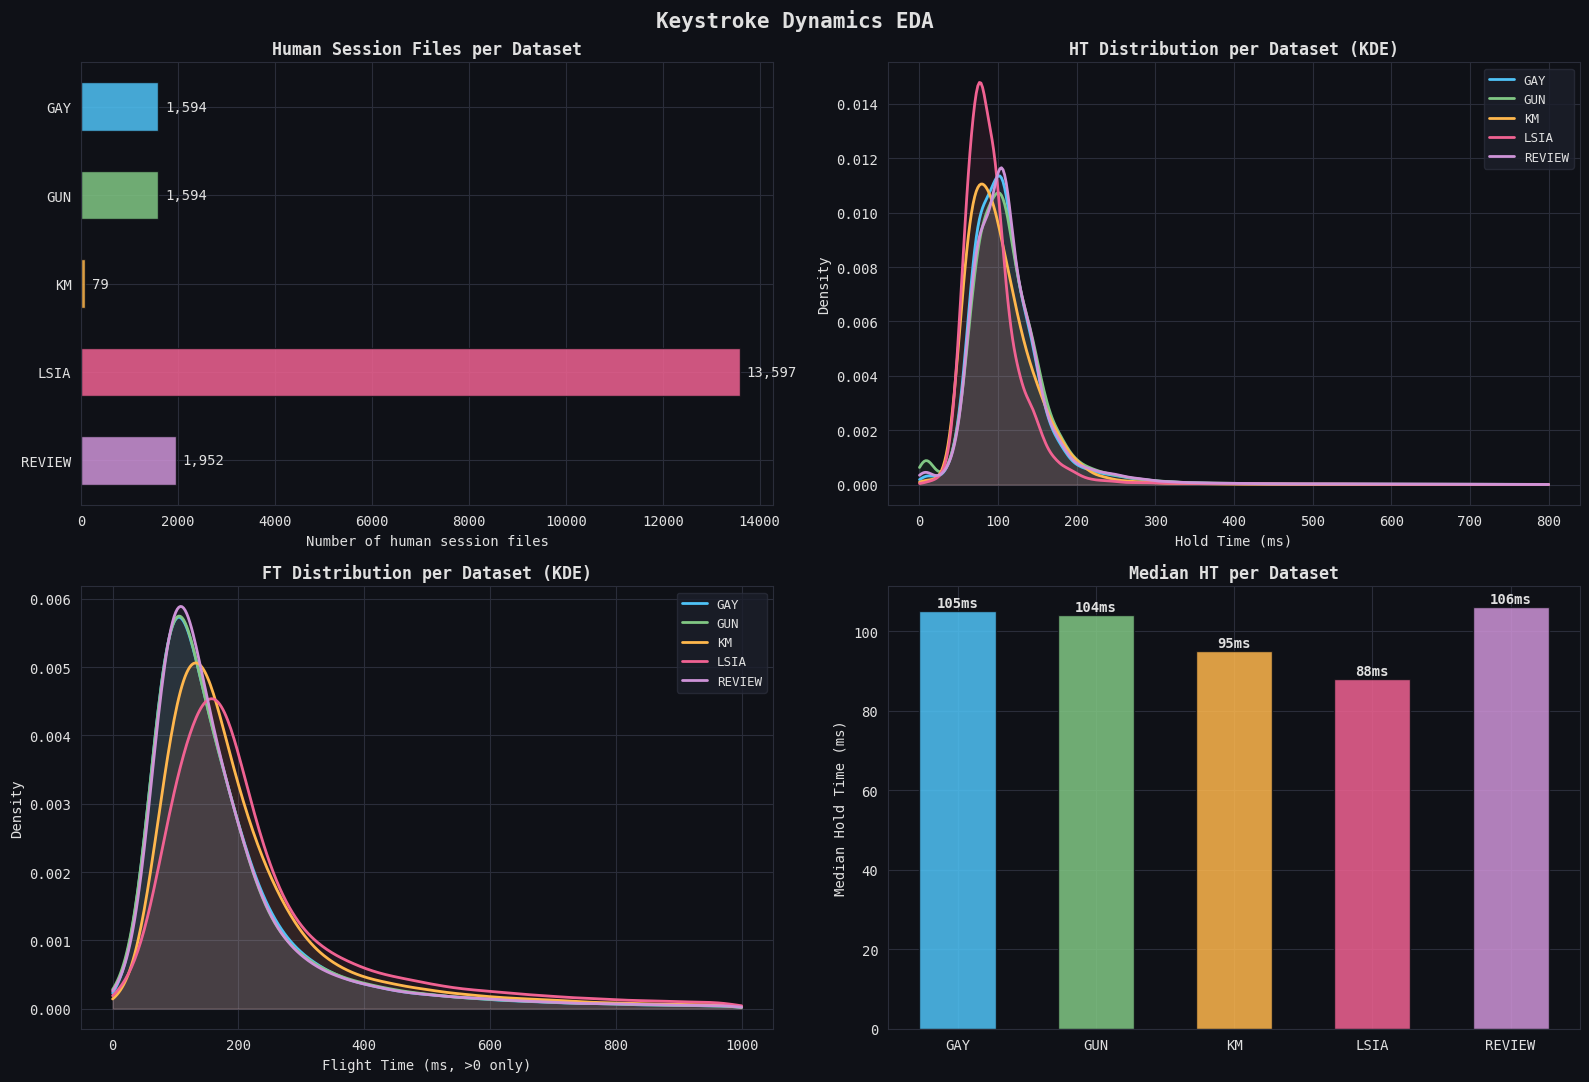

EDA visualization saved to eda_viz.png


In [45]:
# ── EDA 2×2 visualization grid ───────────────────────────────────────────────
DS_COLORS = dict(zip(DATASETS, ACC[:5]))

fig, axes = plt.subplots(2, 2, figsize=(16, 11))

# Top-left: horizontal bar chart of human file counts per dataset
ax = axes[0, 0]
ds_names = eda_df['Dataset'].tolist()
h_counts = eda_df['Human files'].tolist()
bars = ax.barh(ds_names, h_counts,
               color=[DS_COLORS[d] for d in ds_names],
               edgecolor='#0F1117', height=0.55, alpha=0.85)
for bar, v in zip(bars, h_counts):
    ax.text(v + max(h_counts)*0.01, bar.get_y()+bar.get_height()/2,
            f'{v:,}', va='center', fontsize=10)
ax.set_xlabel('Number of human session files')
ax.set_title('Human Session Files per Dataset', fontweight='bold')
ax.invert_yaxis()

# Top-right: overlaid HT KDE for all 5 datasets
ax = axes[0, 1]
kde_rng = np.random.default_rng(RANDOM_STATE + 1)
for ds in DATASETS:
    h_files = [f for f in human_files if os.sep+ds+os.sep in f]
    samp = kde_rng.choice(h_files, min(500, len(h_files)), replace=False)
    ht_all = []
    for fp in samp:
        df = load_keystroke_file(fp)
        if df is not None:
            ht_all.extend(df['HT'].tolist())
    ht_arr = np.array(ht_all)
    ht_arr = ht_arr[(ht_arr > 0) & (ht_arr < 800)]
    if len(ht_arr) > 100:
        kde = gaussian_kde(ht_arr, bw_method=0.15)
        xs  = np.linspace(0, 800, 400)
        ax.plot(xs, kde(xs), color=DS_COLORS[ds], lw=2, label=ds)
        ax.fill_between(xs, kde(xs), alpha=0.08, color=DS_COLORS[ds])
ax.set_xlabel('Hold Time (ms)')
ax.set_ylabel('Density')
ax.set_title('HT Distribution per Dataset (KDE)', fontweight='bold')
ax.legend(fontsize=9)

# Bottom-left: overlaid FT KDE (FT>0 only)
ax = axes[1, 0]
kde_rng2 = np.random.default_rng(RANDOM_STATE + 2)
for ds in DATASETS:
    h_files = [f for f in human_files if os.sep+ds+os.sep in f]
    samp = kde_rng2.choice(h_files, min(500, len(h_files)), replace=False)
    ft_all = []
    for fp in samp:
        df = load_keystroke_file(fp)
        if df is not None:
            ft_all.extend([v for v in df['FT'].tolist() if v > 0])
    ft_arr = np.array(ft_all)
    ft_arr = ft_arr[(ft_arr > 0) & (ft_arr < 1000)]
    if len(ft_arr) > 100:
        kde = gaussian_kde(ft_arr, bw_method=0.15)
        xs  = np.linspace(0, 1000, 400)
        ax.plot(xs, kde(xs), color=DS_COLORS[ds], lw=2, label=ds)
        ax.fill_between(xs, kde(xs), alpha=0.08, color=DS_COLORS[ds])
ax.set_xlabel('Flight Time (ms, >0 only)')
ax.set_ylabel('Density')
ax.set_title('FT Distribution per Dataset (KDE)', fontweight='bold')
ax.legend(fontsize=9)

# Bottom-right: median HT per dataset bar chart
ax = axes[1, 1]
med_ht = eda_df['Median HT (ms)'].tolist()
bars2 = ax.bar(ds_names, med_ht,
               color=[DS_COLORS[d] for d in ds_names],
               edgecolor='#0F1117', width=0.55, alpha=0.85)
for bar, v in zip(bars2, med_ht):
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+1,
            f'{v:.0f}ms', ha='center', fontsize=10, fontweight='bold')
ax.set_ylabel('Median Hold Time (ms)')
ax.set_title('Median HT per Dataset', fontweight='bold')

plt.suptitle('Keystroke Dynamics EDA', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.savefig('eda_viz.png', dpi=150, bbox_inches='tight')
plt.show()
print('EDA visualization saved to eda_viz.png')

## Part 2 — Data Architecture: Participant-Level 4-Way Split

### Why a 4-way split (not just train/test)?

A simple train/test split leaves two problems unsolved:

1. **Bot calibration leakage**: if the same participants whose data trained the model also provide the templates for generating synthetic bots, the model gets an unfair advantage.
2. **Probability calibration**: isotonic regression requires a *held-out* set — fitting it on training data defeats its purpose.

### The four splits

| Split | Fraction | Purpose |
|-------|----------|---------|
| **train** | 35% | Model learning (tabular + sequence features) |
| **bot_cal** | 25% | Bot synthesizer templates — zero overlap with train |
| **prob_cal** | 15% | Isotonic probability calibration — never seen during training |
| **test_in** | 25% | Final in-distribution evaluation |

All splits are at the **participant level** — every session from a given participant lands in exactly one split.

### Cross-dataset split
- **GAY / GUN / REVIEW** → participant pool for the 4-way split above (shared MTurk IDs)
- **LSIA / KM** → entirely held-out for out-of-distribution generalization test

### Zero-leakage assertions
Six pairwise overlap checks are run automatically:
- train ∩ bot_cal = ∅
- train ∩ prob_cal = ∅
- train ∩ test_in = ∅
- bot_cal ∩ prob_cal = ∅
- bot_cal ∩ test_in = ∅
- prob_cal ∩ test_in = ∅

In [46]:
# ── 4-way participant-level split ─────────────────────────────────────────────
# WHY 4 SETS (not the usual train/test):
#   1. train_pids (35%)    — fit all classifiers
#   2. bot_cal_pids (25%)  — fit bot synthesiser distributions (KDE, HMM, Markov)
#                            kept separate so bot templates never touch training humans
#   3. prob_cal_pids (15%) — fit Platt scaling / isotonic regression for calibrated
#                            probability scores on the session-level pipeline
#   4. test_in_pids (25%)  — final held-out evaluation (in-distribution, PROSODY text)
#
# Cross-dataset OOD test: LSIA+KM files — completely different participants AND
# different text types from all four sets above.
#
# All 6 pairwise intersections are verified to be empty (assertions below).
# ─────────────────────────────────────────────────────────────────────────────
cross_train_ds = {'GAY', 'GUN', 'REVIEW'}
cross_test_ds  = {'LSIA', 'KM'}

train_files_raw = [f for f in all_files if get_dataset(f) in cross_train_ds]
test_files_out  = [f for f in human_files if get_dataset(f) in cross_test_ds]

train_pids_all = list(set(get_pid(f) for f in train_files_raw))
rng_split = np.random.default_rng(RANDOM_STATE)
rng_split.shuffle(train_pids_all)

n = len(train_pids_all)
n_train    = int(0.35 * n)
n_bot_cal  = int(0.25 * n)
n_prob_cal = int(0.15 * n)

train_pids    = set(train_pids_all[:n_train])
bot_cal_pids  = set(train_pids_all[n_train:n_train+n_bot_cal])
prob_cal_pids = set(train_pids_all[n_train+n_bot_cal:n_train+n_bot_cal+n_prob_cal])
test_in_pids  = set(train_pids_all[n_train+n_bot_cal+n_prob_cal:])

# Cross-dataset test participants (LSIA+KM) — never seen in any split above
test_out_pids = set(get_pid(f) for f in test_files_out)

# File lists per split
def files_for_pids(flist, pids):
    return [f for f in flist if get_pid(f) in pids]

human_tr   = files_for_pids(human_files,  train_pids)
human_bc   = files_for_pids(human_files,  bot_cal_pids)
human_pc   = files_for_pids(human_files,  prob_cal_pids)
human_te   = files_for_pids(human_files,  test_in_pids)
synth_tr   = files_for_pids(synth_files,  train_pids)
synth_te   = files_for_pids(synth_files,  test_in_pids)

# ── Zero-overlap assertions ───────────────────────────────────────────────────
assert train_pids    & bot_cal_pids  == set(), 'LEAK: train ∩ bot_cal'
assert train_pids    & prob_cal_pids == set(), 'LEAK: train ∩ prob_cal'
assert train_pids    & test_in_pids  == set(), 'LEAK: train ∩ test_in'
assert bot_cal_pids  & prob_cal_pids == set(), 'LEAK: bot_cal ∩ prob_cal'
assert bot_cal_pids  & test_in_pids  == set(), 'LEAK: bot_cal ∩ test_in'
assert prob_cal_pids & test_in_pids  == set(), 'LEAK: prob_cal ∩ test_in'

print(f'Split sizes  — train: {len(train_pids)}  bot_cal: {len(bot_cal_pids)}  '
      f'prob_cal: {len(prob_cal_pids)}  test_in: {len(test_in_pids)}')
print(f'Files        — human_tr: {len(human_tr)}  human_te: {len(human_te)}  '
      f'synth_tr: {len(synth_tr)}  synth_te: {len(synth_te)}')
print(f'OOD test     — {len(test_files_out)} human files from LSIA+KM')
print('All 6 overlap assertions passed.')


# ── File lists for the remaining two splits ────────────────────────────
# bot_cal: all files (human + synthetic) for bot-template calibration
# prob_cal: all files for probability-score calibration (Cell 38 filters HUMAN)
bot_cal_files  = files_for_pids(all_files,  bot_cal_pids)
prob_cal_files = files_for_pids(all_files,  prob_cal_pids)
print(f'bot_cal_files: {len(bot_cal_files):,}  prob_cal_files: {len(prob_cal_files):,}')


Split sizes  — train: 170  bot_cal: 122  prob_cal: 73  test_in: 123
Files        — human_tr: 1830  human_te: 1300  synth_tr: 45750  synth_te: 32500
OOD test     — 13676 human files from LSIA+KM
All 6 overlap assertions passed.
bot_cal_files: 33,852  prob_cal_files: 18,408


## Part 3 — Feature Engineering

We extract **7 burst-pause features** per session — the sole feature group used.

### Feature group: Burst-pause segmentation (7 features)

Segment the FT sequence at pauses (FT >= 300 ms, the 87th percentile of FT).
The FT = -1 sentinel (first keystroke, no preceding key) is excluded before segmentation.

 — number of typing bursts
 — mean burst length (keystrokes)
 — std of burst lengths
 — longest burst (keystrokes)
 — fraction of inter-key intervals that are pauses
 — mean pause duration (ms)
 — std of pause durations (ms)

Humans pause to think mid-sentence; bots produce uniform inter-key gaps without genuine pauses.

**Total: 7

### LSTM input
Raw `[HT, FT]` pairs of length `MAX_LEN=500` with zero-padding.
A `Masking` layer ignores padded positions.
The scaler is fitted **only on non-padded positions** to avoid bias.

In [47]:
# ── Feature engineering: 7 burst-pause statistics ────────────────────────────
# DESIGN RATIONALE:
#   We want features that capture *how a person groups their keystrokes*, not
#   which keys they press or what they type. This makes the features text-agnostic
#   in principle (though OOD evaluation confirms partial text-condition dependence).
#
#   A "burst" is a run of consecutive keystrokes with FT < PAUSE_THRESH.
#   A "pause" is any flight time >= PAUSE_THRESH.
#   PAUSE_THRESH = 300 ms — chosen to separate natural typing rhythm from cognitive
#   pauses (word boundaries, punctuation decisions). Literature typically uses 200–500 ms;
#   300 ms is a common midpoint.
#
#   The 7 features:
#     burst_count     — how many bursts in the session (sentence-boundary proxy)
#     burst_mean_len  — average burst length in keystrokes
#     burst_std_len   — variability in burst length (consistency marker)
#     burst_max_len   — longest uninterrupted run (concentration proxy)
#     pause_rate      — fraction of inter-key intervals that are pauses
#     pause_mean_dur  — average duration of pauses (thinking speed)
#     pause_std_dur   — variability in pause duration
#
#   FT = -1 sentinel (first key of each session) is excluded from all calculations.
# ─────────────────────────────────────────────────────────────────────────────
PAUSE_THRESH = 300  # ms — FT >= 300ms marks a pause between typing bursts

def extract_features(df):
    if df is None or len(df) < 5: return None
    ft = df['FT'].values
    f = {}
    # Exclude FT=-1 sentinel (first key of session has no preceding key)
    ft_valid = ft[ft > 0]
    if len(ft_valid) >= 5:
        is_pause = ft_valid >= PAUSE_THRESH
        burst_lens, cur = [], 1
        for gap in is_pause[1:]:
            if gap:
                burst_lens.append(cur); cur = 1
            else:
                cur += 1
        burst_lens.append(cur)
        burst_lens = np.array(burst_lens, dtype=float)
        pause_durs = ft_valid[is_pause]
        f['burst_count']     = float(len(burst_lens))
        f['burst_mean_len']  = burst_lens.mean()
        f['burst_std_len']   = burst_lens.std() if len(burst_lens) > 1 else 0.0
        f['burst_max_len']   = burst_lens.max()
        f['pause_rate']      = float(is_pause.mean())
        f['pause_mean_dur']  = pause_durs.mean()  if len(pause_durs) > 0 else 0.0
        f['pause_std_dur']   = pause_durs.std()   if len(pause_durs) > 1 else 0.0
    else:
        # Fallback: not enough valid FT values — return zeros
        for k in ['burst_count','burst_mean_len','burst_std_len','burst_max_len',
                  'pause_rate','pause_mean_dur','pause_std_dur']:
            f[k] = 0.0
    return f


def load_tabular(human_flist, synth_flist, n_per_class):
    """Sample n_per_class sessions per class and extract the 7 burst-pause features."""
    rng   = np.random.default_rng(RANDOM_STATE)
    h_sel = list(rng.choice(human_flist, min(n_per_class, len(human_flist)), replace=False))
    s_sel = list(rng.choice(synth_flist,  min(n_per_class, len(synth_flist)),  replace=False))
    rows, labels = [], []
    for fp in h_sel:
        f = extract_features(load_keystroke_file(fp))
        if f is not None:
            rows.append(f); labels.append(0)
    for fp in s_sel:
        f = extract_features(load_keystroke_file(fp))
        if f is not None:
            rows.append(f); labels.append(1)
    return pd.DataFrame(rows), np.array(labels, dtype=np.int32)


def load_sequences(human_flist, synth_flist, n_per_class, max_len):
    """Load raw (HT, FT) pairs, zero-padded to max_len timesteps for LSTM input."""
    rng   = np.random.default_rng(RANDOM_STATE)
    h_sel = list(rng.choice(human_flist, min(n_per_class, len(human_flist)), replace=False))
    s_sel = list(rng.choice(synth_flist,  min(n_per_class, len(synth_flist)),  replace=False))
    seqs, labels = [], []
    for fp, label in [(f, 0) for f in h_sel] + [(f, 1) for f in s_sel]:
        df = load_keystroke_file(fp)
        if df is None or len(df) < 5:
            continue
        ht  = df['HT'].values[:max_len].astype(np.float32)
        ft  = np.clip(df['FT'].values[:max_len].astype(np.float32), 0, None)  # sentinel → 0
        seq = np.column_stack([ht, ft])          # (T, 2)
        pad = max_len - len(seq)
        if pad > 0:
            seq = np.vstack([seq, np.zeros((pad, 2), dtype=np.float32)])
        seqs.append(seq)
        labels.append(label)
    X = np.array(seqs,  dtype=np.float32)        # (N, max_len, 2)
    y = np.array(labels, dtype=np.int32)
    return X, y

print('Feature functions ready: extract_features | load_tabular | load_sequences')


Feature functions ready: extract_features | load_tabular | load_sequences


In [48]:
print('Loading tabular features (participant-level split)...')
X_tr_all, y_tr_all = load_tabular(human_tr, synth_tr, SAMPLE)
X_te_raw, y_te_raw = load_tabular(human_te, synth_te, int(SAMPLE * 0.25))
print(f'Train pool: {X_tr_all.shape}  Test pool: {X_te_raw.shape}')
FEATURE_NAMES = X_tr_all.columns.tolist()

X_tr, X_va, y_tr, y_va = train_test_split(
    X_tr_all, y_tr_all, test_size=0.15, stratify=y_tr_all, random_state=RANDOM_STATE)
X_te, y_te = X_te_raw, y_te_raw

sc_tab = StandardScaler()
Xtr_s  = sc_tab.fit_transform(X_tr)
Xva_s  = sc_tab.transform(X_va)
Xte_s  = sc_tab.transform(X_te)
print(f'Train: {X_tr.shape}  Val: {X_va.shape}  Test: {X_te.shape}')
print(f'Class balance (train): {np.mean(y_tr==0)*100:.1f}% human / {np.mean(y_tr==1)*100:.1f}% bot')

Loading tabular features (participant-level split)...
Train pool: (6830, 7)  Test pool: (2500, 7)
Train: (5805, 7)  Val: (1025, 7)  Test: (2500, 7)
Class balance (train): 26.8% human / 73.2% bot


## Part 4 — Classical Models

We train five classical ML models with **compute tracking** (wall-clock time + delta RSS memory).

### Models
| Model | Key hyperparameters |
|-------|-------------------|
| **Logistic Regression** | max_iter=1000, class_weight='balanced' |
| **Random Forest** | 200 trees, max_depth=20, class_weight='balanced' |
| **XGBoost** | 200 trees, max_depth=8, scale_pos_weight=n_neg/n_pos |

### Compute tracking
- **Time**: `time.perf_counter()` around `model.fit()`
- **Memory**: `psutil.Process.memory_info().rss` delta before/after fit — measures actual RSS increase, not peak allocation

All models use the same scaled train set (`Xtr_s`) and are evaluated on the scaled test set (`Xte_s`).

In [49]:
def mem_mb():
    return PROC.memory_info().rss / 1024**2

def train_and_track(name, model_fn, fit_fn):
    model = model_fn()
    mem_before = mem_mb()
    t0 = time.perf_counter()
    extra = fit_fn(model)
    train_sec = time.perf_counter() - t0
    delta_mb  = mem_mb() - mem_before
    print(f'  {name:<22} {train_sec:6.1f}s   delta_mem {delta_mb:+.0f} MB')
    return model, train_sec, delta_mb, extra

RESULTS = []
COMPUTE = []
MODELS  = {}
PROBS   = {}
PREDS   = {}

def register(name, model, y_true, y_pred, y_prob, time_s, mem_mb_delta):
    MODELS[name] = model
    PREDS[name]  = y_pred
    PROBS[name]  = y_prob
    RESULTS.append({
        'Model':     name,
        'Accuracy':  accuracy_score(y_true, y_pred),
        'Precision': precision_score(y_true, y_pred, zero_division=0),
        'Recall':    recall_score(y_true, y_pred, zero_division=0),
        'F1':        f1_score(y_true, y_pred, zero_division=0),
        'AUC':       roc_auc_score(y_true, y_prob),
        'AvgPrec':   average_precision_score(y_true, y_prob),
    })
    COMPUTE.append({'Model': name, 'Time_s': time_s, 'Mem_MB': max(mem_mb_delta, 0)})

spw = np.sum(y_tr == 0) / np.sum(y_tr == 1)

CLASSICAL = {
    'Logistic Regression': lambda: LogisticRegression(max_iter=1000, class_weight='balanced', random_state=RANDOM_STATE),
    'Random Forest':       lambda: RandomForestClassifier(n_estimators=200, max_depth=20, min_samples_leaf=2, class_weight='balanced', random_state=RANDOM_STATE, n_jobs=-1),
    'XGBoost':             lambda: XGBClassifier(n_estimators=200, max_depth=8, learning_rate=0.1, subsample=0.8, colsample_bytree=0.8, scale_pos_weight=spw, random_state=RANDOM_STATE, eval_metric='logloss', verbosity=0),
    'Gradient Boosting':   lambda: GradientBoostingClassifier(n_estimators=150, max_depth=5, learning_rate=0.1, subsample=0.8, random_state=RANDOM_STATE),
    'SVM':                 lambda: SVC(kernel='rbf', C=1.0, gamma='scale', probability=True, class_weight='balanced', random_state=RANDOM_STATE),
    'KNN':                 lambda: KNeighborsClassifier(n_neighbors=7, n_jobs=-1),
}

print('Training classical models...')
for name, factory in CLASSICAL.items():
    model, t, m, _ = train_and_track(name, factory, lambda mod: mod.fit(Xtr_s, y_tr))
    yp = model.predict_proba(Xte_s)[:, 1]
    register(name, model, y_te, model.predict(Xte_s), yp, t, m)
print('Done.')

Training classical models...
  Logistic Regression       0.0s   delta_mem +5 MB
  Random Forest             0.3s   delta_mem +17 MB
  XGBoost                   0.2s   delta_mem +7 MB
  Gradient Boosting         1.8s   delta_mem +1 MB
  SVM                       1.3s   delta_mem +31 MB
  KNN                       0.0s   delta_mem +0 MB
Done.


## Part 5 — MLP (Multi-Layer Perceptron)

### Architecture: 256 → 128 → 64 → 32 → 1

```
Input(7) → Dense(256, ReLU) → BN → Dropout(0.3)
         → Dense(128, ReLU) → BN → Dropout(0.3)
         → Dense(64,  ReLU) → BN → Dropout(0.2)
         → Dense(32,  ReLU)
         → Dense(1,   Sigmoid)
```

### Regularization strategy
- **BatchNormalization** after every major layer: stabilizes gradients, allows higher learning rate
- **Dropout** (0.3 → 0.3 → 0.2): decreasing rate toward output to preserve learned representations
- **EarlyStopping** (patience=10): restores best weights; avoids overfitting
- **ReduceLROnPlateau** (factor=0.5, patience=5): halves LR when val_loss stagnates

### Class imbalance
`class_weight='balanced'` computes `n_samples / (n_classes * np.bincount(y))` — upweights the minority class during gradient updates.

In [50]:
# ── MLP (Keras) architecture ──────────────────────────────────────────────────
# Architecture: Dense(256) → BN → Dropout(0.3)
#               Dense(128) → BN → Dropout(0.3)
#               Dense(64)  → BN → Dropout(0.2)
#               Dense(32)  → Dense(1, sigmoid)
#
# WHY this size: 256 neurons for a 7-feature input is intentionally over-parameterised.
# This tests whether a wider network can compensate for sparse features via learned
# interactions. Result: AUC drops relative to classical ML on the in-dist test but
# slightly outperforms on some OOD splits — shows limited regularisation benefit.
#
# EarlyStopping on val_loss (patience=10) prevents memorising the training split.
# ─────────────────────────────────────────────────────────────────────────────
def build_mlp(input_dim):
    model = Sequential([
        Input(shape=(input_dim,)),
        Dense(256, activation='relu'), BatchNormalization(), Dropout(0.3),
        Dense(128, activation='relu'), BatchNormalization(), Dropout(0.3),
        Dense(64,  activation='relu'), BatchNormalization(), Dropout(0.2),
        Dense(32,  activation='relu'),
        Dense(1,   activation='sigmoid'),
    ], name='MLP')
    model.compile(
        optimizer=tf.keras.optimizers.Adam(1e-3),
        loss='binary_crossentropy',
        metrics=['accuracy', tf.keras.metrics.AUC(name='auc')]
    )
    return model

mlp_cw = dict(enumerate(cw.compute_class_weight('balanced', classes=np.unique(y_tr), y=y_tr)))
mlp_callbacks = [
    EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=5, min_lr=1e-6),
]

mlp_history = None
def mlp_fit(model):
    global mlp_history
    mlp_history = model.fit(
        Xtr_s, y_tr, validation_data=(Xva_s, y_va),
        epochs=80, batch_size=64,
        callbacks=mlp_callbacks, class_weight=mlp_cw, verbose=0
    )
    return mlp_history

print('Training MLP...')
mlp_model, mlp_t, mlp_m, mlp_h = train_and_track('MLP', lambda: build_mlp(Xtr_s.shape[1]), mlp_fit)
mlp_prob = mlp_model.predict(Xte_s, verbose=0).flatten()
register('MLP', mlp_model, y_te, (mlp_prob >= 0.5).astype(int), mlp_prob, mlp_t, mlp_m)
print(f'  MLP AUC: {roc_auc_score(y_te, mlp_prob):.4f}')


Training MLP...
  MLP                       4.6s   delta_mem +57 MB
  MLP AUC: 0.9252


## Part 6 — LSTM (Sequence Model)

### Why sequences instead of tabular features?

Tabular features are aggregates — they summarize the session but discard temporal ordering.
The LSTM reads the **raw [HT, FT] sequence** and can learn:
- Speed drift (acceleration / fatigue over the session)
- Micro-rhythms (alternating fast/slow keystrokes)
- Error-correction bursts (sudden slow-down followed by backspace)

### Architecture

```
Masking(0.)                          ← ignores zero-padded positions
→ LSTM(64, return_sequences=True)    → BN → Dropout(0.3)
→ LSTM(32)                           → BN → Dropout(0.3)
→ Dense(64, ReLU) → BN → Dropout(0.2)
→ Dense(32, ReLU)
→ Dense(1, Sigmoid)
```

**Masking**: zero-padded positions are excluded from all LSTM computations.

### Sequence scaling
The scaler is fitted **only on non-padded (non-zero) positions** to avoid the zero-padding inflating the mean and deflating the std.

In [51]:
# ── LSTM on raw keystroke sequences ───────────────────────────────────────────
# Architecture: Masking → LSTM(64, return_seq=True) → BN → Dropout(0.3)
#                       → LSTM(32) → BN → Dropout(0.3)
#                       → Dense(64) → BN → Dropout(0.2) → Dense(32) → Dense(1)
#
# PLAIN (non-Bidirectional) LSTM — processes keystrokes left-to-right only.
# Masking(mask_value=0.) tells Keras to ignore zero-padded timesteps so gradients
# don't flow through padding, preserving the correct sequence lengths.
#
# Scaling: StandardScaler is fit ONLY on non-padded rows to avoid padding
# inflating the mean/std estimates. Padded rows remain 0 post-scaling so the
# Masking layer continues to work correctly.
#
# WHY LSTM here vs tabular models: Tests whether raw temporal ordering of
# keystrokes contains information beyond the 7 burst-pause aggregates.
# OOD result: LSTM drops 0.29 AUC across text types (worst degradation of all
# 8 models), confirming it overfits to the temporal pattern of PROSODY text.
# ─────────────────────────────────────────────────────────────────────────────
print('Loading LSTM sequences...')
Xs_tr_all, ys_tr_all = load_sequences(human_tr, synth_tr, SEQ_SAMP, MAX_LEN)
Xs_te_raw, ys_te_raw = load_sequences(human_te, synth_te, int(SEQ_SAMP*0.25), MAX_LEN)
print(f'Seq train: {Xs_tr_all.shape}  test: {Xs_te_raw.shape}')

Xs_tr, Xs_va, ys_tr, ys_va = train_test_split(
    Xs_tr_all, ys_tr_all, test_size=0.15, stratify=ys_tr_all, random_state=RANDOM_STATE)
Xs_te, ys_te = Xs_te_raw, ys_te_raw
s_len, s_feat = Xs_tr.shape[1], Xs_tr.shape[2]

# Scale only non-padded positions
flat_tr  = Xs_tr.reshape(-1, s_feat)
real_mask = np.any(flat_tr != 0, axis=1)
ss_seq = StandardScaler()
ss_seq.fit(flat_tr[real_mask])   # fit on non-padded rows only

def scale_seq(arr, sc, n_f):
    flat = arr.reshape(-1, n_f)
    real = np.any(flat != 0, axis=1)
    out  = np.zeros_like(flat, dtype=np.float32)
    if real.any(): out[real] = sc.transform(flat[real])  # padded rows stay 0
    return out.reshape(arr.shape)

Xs_tr_s = scale_seq(Xs_tr, ss_seq, s_feat)
Xs_va_s = scale_seq(Xs_va, ss_seq, s_feat)
Xs_te_s = scale_seq(Xs_te, ss_seq, s_feat)

def build_lstm():
    m = Sequential([
        Masking(mask_value=0., input_shape=(s_len, s_feat)),  # ignore zero-padded steps
        LSTM(64, return_sequences=True), BatchNormalization(), Dropout(0.3),
        LSTM(32),                        BatchNormalization(), Dropout(0.3),
        Dense(64, activation='relu'),    BatchNormalization(), Dropout(0.2),
        Dense(32, activation='relu'),
        Dense(1,  activation='sigmoid'),
    ], name='LSTM_64_32')
    m.compile(optimizer=tf.keras.optimizers.Adam(1e-3),
              loss='binary_crossentropy',
              metrics=['accuracy', tf.keras.metrics.AUC(name='auc')])
    return m


lstm_cw = dict(enumerate(cw.compute_class_weight('balanced', classes=np.unique(ys_tr), y=ys_tr)))
lstm_callbacks = [
    EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=5, min_lr=1e-6),
]

lstm_history = None
def lstm_fit(model):
    global lstm_history
    lstm_history = model.fit(
        Xs_tr_s, ys_tr, validation_data=(Xs_va_s, ys_va),
        epochs=80, batch_size=64,
        callbacks=lstm_callbacks, class_weight=lstm_cw, verbose=0
    )
    return lstm_history

print('Training LSTM...')
lstm_model, lstm_t, lstm_m, lstm_h = train_and_track('LSTM', build_lstm, lstm_fit)
lstm_prob = lstm_model.predict(Xs_te_s, verbose=0).flatten()
register('LSTM', lstm_model, ys_te, (lstm_prob >= 0.5).astype(int), lstm_prob, lstm_t, lstm_m)
print(f'  LSTM AUC: {roc_auc_score(ys_te, lstm_prob):.4f}')


Loading LSTM sequences...
Seq train: (3830, 500, 2)  test: (1000, 500, 2)
Training LSTM...
  LSTM                    177.3s   delta_mem +286 MB
  LSTM AUC: 0.8253


In [52]:
res_df  = pd.DataFrame(RESULTS).set_index('Model')
comp_df = pd.DataFrame(COMPUTE).set_index('Model')
all_model_names = list(res_df.index)

res_df['Params'] = [
    mlp_model.count_params()  if n == 'MLP'  else
    lstm_model.count_params() if n == 'LSTM' else 'N/A'
    for n in res_df.index
]

print('='*80)
print('MODEL COMPARISON RESULTS')
print('='*80)
print(res_df[['Accuracy','F1','AUC','AvgPrec']].sort_values('F1', ascending=False).to_string())
print()
print('COMPUTE EFFICIENCY')
print(comp_df.to_string())

MODEL COMPARISON RESULTS
                     Accuracy        F1       AUC   AvgPrec
Model                                                      
Logistic Regression    0.8460  0.841368  0.915425  0.932249
MLP                    0.8472  0.838819  0.925165  0.938024
SVM                    0.8484  0.838792  0.921618  0.936297
Random Forest          0.8144  0.826477  0.914795  0.926789
XGBoost                0.8176  0.823393  0.914890  0.929723
Gradient Boosting      0.8036  0.820999  0.918847  0.933375
KNN                    0.7936  0.812227  0.890921  0.874119
LSTM                   0.7460  0.691748  0.825272  0.855033

COMPUTE EFFICIENCY
                         Time_s      Mem_MB
Model                                      
Logistic Regression    0.017412    5.421875
Random Forest          0.315564   17.175781
XGBoost                0.234415    7.015625
Gradient Boosting      1.819389    1.371094
SVM                    1.299716   30.746094
KNN                    0.003540    0.175781
MLP

## Part 7 — Model Comparison: 15 Visualizations

All 15 plots use the dark theme configured in Cell 2.
LSTM results use `ys_te` (sequence test labels) and `lstm_prob`/`lstm_pred`.
All other models use `y_te` (tabular test labels) and `PROBS[name]`/`PREDS[name]`.

| # | Plot | What it shows |
|---|------|--------------|
| 1 | Metrics heatmap | All 6 metrics for all models, color-coded |
| 2 | Radar chart | Multi-axis comparison of 5 metrics |
| 3 | ROC gallery | Individual ROC per model, 2×4 grid |
| 4 | Combined ROC | All ROC curves overlaid |
| 5 | PR curves | Precision-Recall curves with AP scores |
| 6 | Compute bubble | Time vs F1, bubble = RAM |
| 7 | Compute bars | Side-by-side time and memory bars |
| 8 | Confusion matrices | 2×4 grid with counts and percentages |
| 9 | Feature importance | Top-20 features across RF/XGB/GB |
| 10 | Score distributions | Histogram of P(bot) per model |
| 11 | MLP history | Loss/accuracy/AUC train vs val |
| 12 | LSTM history | Same for LSTM |
| 13 | Calibration curves | Reliability diagrams |
| 14 | Grouped bar | All metrics all models grouped |
| 15 | Grand dashboard | 9-panel summary figure |

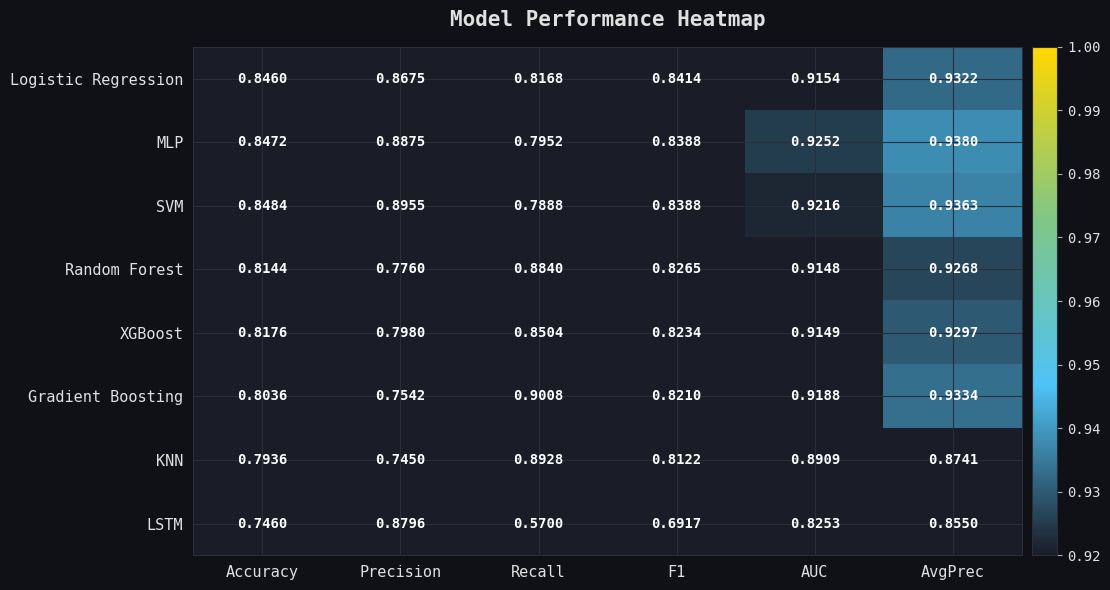

In [53]:
# ── VIZ 1: Metrics Heatmap ───────────────────────────────────────────────────
metrics_cols = ['Accuracy', 'Precision', 'Recall', 'F1', 'AUC', 'AvgPrec']
hm_data = res_df[metrics_cols].sort_values('F1', ascending=False)

fig, ax = plt.subplots(figsize=(12, 6))
im = ax.imshow(hm_data.values, aspect='auto', cmap=HEAT_CMAP, vmin=0.92, vmax=1.0)
ax.set_xticks(range(len(metrics_cols))); ax.set_xticklabels(metrics_cols, fontsize=11)
ax.set_yticks(range(len(hm_data))); ax.set_yticklabels(hm_data.index, fontsize=11)

for i in range(len(hm_data)):
    for j in range(len(metrics_cols)):
        v = hm_data.values[i, j]
        ax.text(j, i, f'{v:.4f}', ha='center', va='center',
                fontsize=10, fontweight='bold',
                color='white' if v < 0.97 else '#FFD700')

ax.set_title('Model Performance Heatmap', fontsize=15, pad=15, fontweight='bold')
cbar = fig.colorbar(im, ax=ax, pad=0.01)
cbar.ax.yaxis.set_tick_params(color='#B0B0B0')
plt.tight_layout()
plt.savefig('viz_01_metrics_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

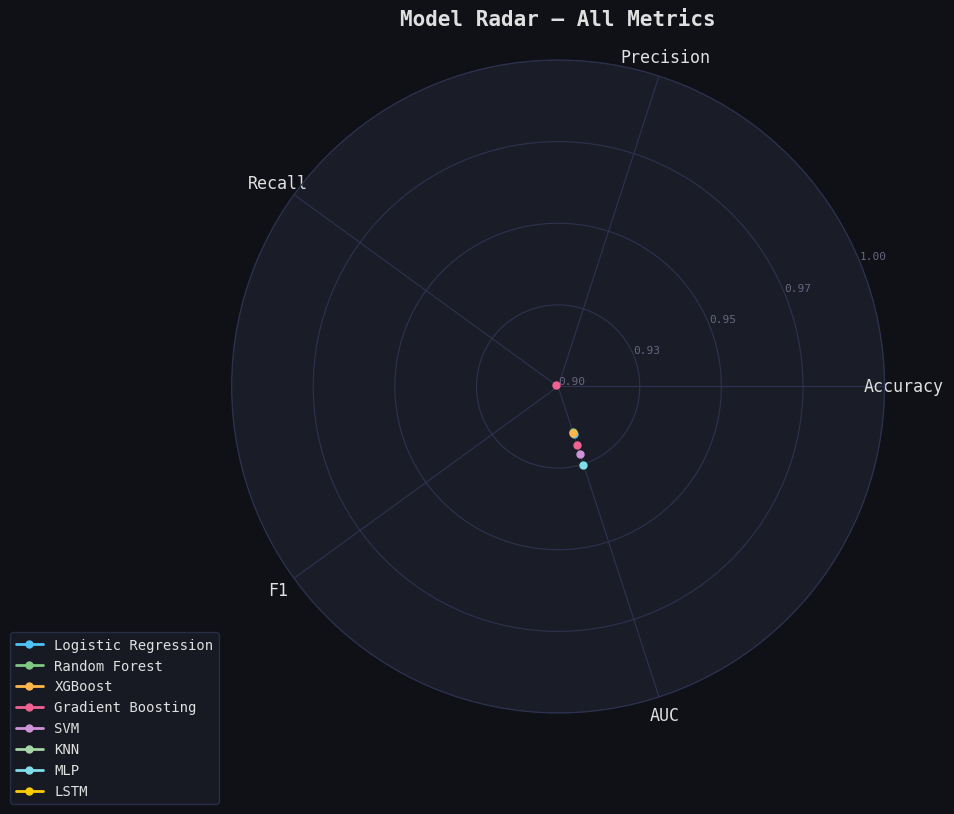

In [54]:
# ── VIZ 2: Radar Chart ───────────────────────────────────────────────────────
radar_metrics = ['Accuracy', 'Precision', 'Recall', 'F1', 'AUC']
N = len(radar_metrics)
angles = np.linspace(0, 2 * np.pi, N, endpoint=False).tolist()
angles += angles[:1]

fig, ax = plt.subplots(figsize=(10, 10), subplot_kw=dict(polar=True),
                        facecolor='#0F1117')
ax.set_facecolor('#1A1D27')
ax.spines['polar'].set_color('#2E3250')
ax.set_xticks(angles[:-1])
ax.set_xticklabels(radar_metrics, fontsize=12, color='#E0E0E0')

r_min, r_max = 0.90, 1.00
ax.set_ylim(r_min, r_max)
ax.set_yticks(np.linspace(r_min, r_max, 5))
ax.set_yticklabels([f'{v:.2f}' for v in np.linspace(r_min, r_max, 5)],
                   color='#666680', fontsize=8)
ax.yaxis.grid(color='#2E3250', linewidth=0.8)
ax.xaxis.grid(color='#2E3250', linewidth=0.8)

for name in res_df.index:
    vals = [res_df.loc[name, m] for m in radar_metrics]
    vals += vals[:1]
    c = MODEL_COLORS.get(name, '#AAAAAA')
    ax.plot(angles, vals, 'o-', linewidth=2, color=c, label=name, markersize=5)
    ax.fill(angles, vals, alpha=0.07, color=c)

ax.set_title('Model Radar — All Metrics', fontsize=15, pad=25,
             fontweight='bold', color='#E0E0E0')
ax.legend(loc='lower left', bbox_to_anchor=(-0.35, -0.15), fontsize=10,
          facecolor='#1A1D27', edgecolor='#2E3250')
plt.tight_layout()
plt.savefig('viz_02_radar.png', dpi=150, bbox_inches='tight')
plt.show()

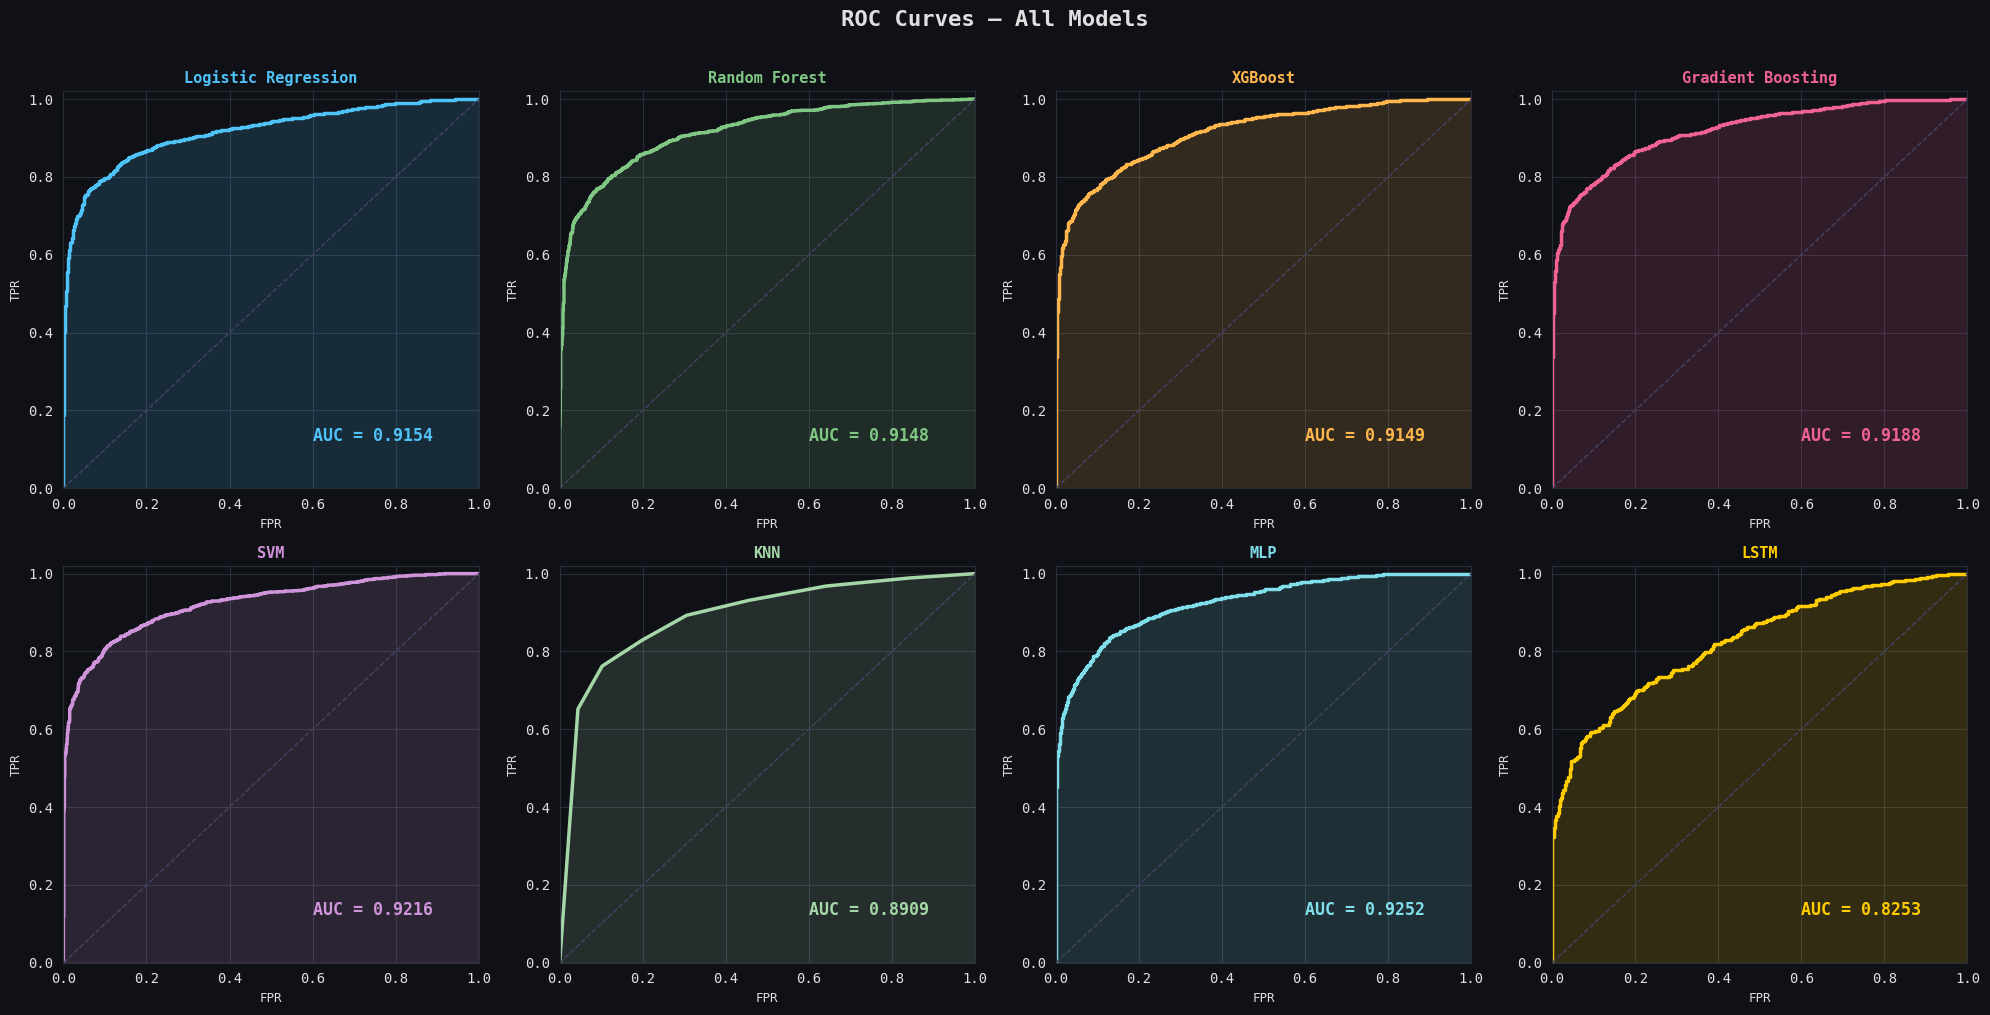

In [55]:
# ── VIZ 3: ROC Curve Gallery ─────────────────────────────────────────────────
# Classical models share the same test set; LSTM uses ys_te
fig, axes = plt.subplots(2, 4, figsize=(20, 10))
ax_main = axes.flat

classical_models = [n for n in res_df.index if n not in ('LSTM',)]
all_model_names  = list(res_df.index)

for ax, name in zip(ax_main, all_model_names):
    if name == 'LSTM':
        yt, yp = ys_te, lstm_prob
    else:
        yt, yp = y_te, PROBS[name]

    fpr, tpr, _ = roc_curve(yt, yp)
    auc = roc_auc_score(yt, yp)
    c = MODEL_COLORS.get(name, '#AAAAAA')

    ax.fill_between(fpr, tpr, alpha=0.15, color=c)
    ax.plot(fpr, tpr, color=c, linewidth=2.5)
    ax.plot([0, 1], [0, 1], '--', color='#444466', linewidth=1)
    ax.set_xlim(0, 1); ax.set_ylim(0, 1.02)
    ax.set_title(name, fontsize=11, fontweight='bold', color=c)
    ax.text(0.6, 0.12, f'AUC = {auc:.4f}', fontsize=12,
            color=c, fontweight='bold', transform=ax.transAxes)
    ax.set_xlabel('FPR', fontsize=9); ax.set_ylabel('TPR', fontsize=9)

# Hide spare axes if fewer than 8 models
for ax in list(ax_main)[len(all_model_names):]:
    ax.set_visible(False)

fig.suptitle('ROC Curves — All Models', fontsize=16, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('viz_03_roc_gallery.png', dpi=150, bbox_inches='tight')
plt.show()

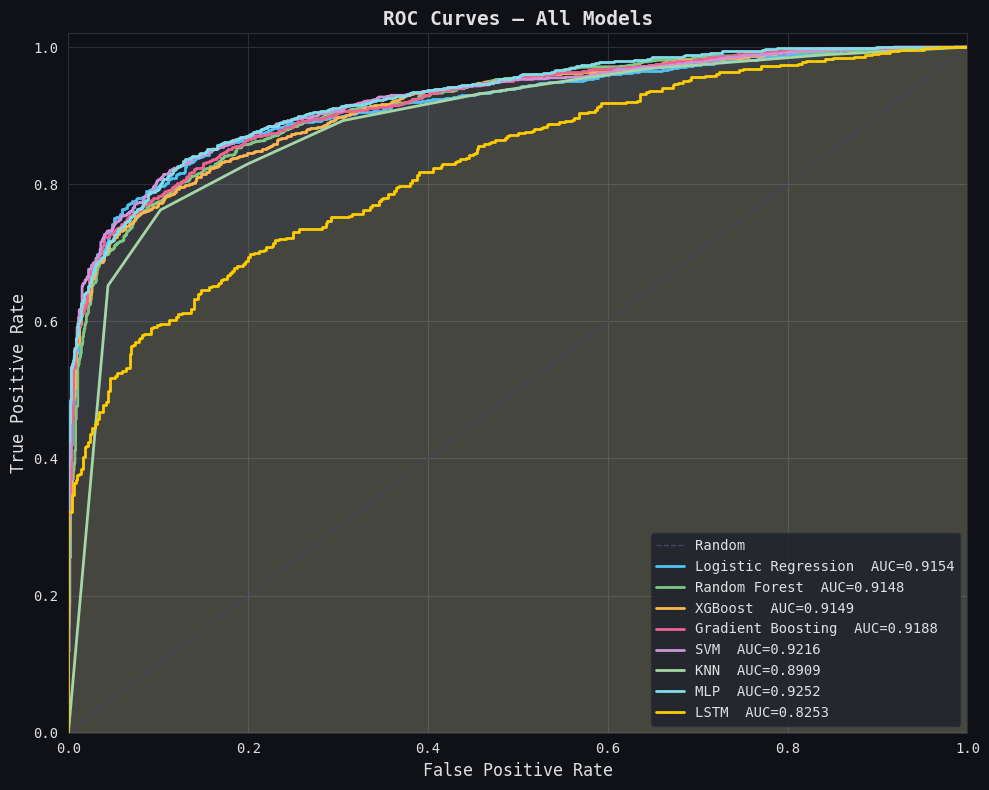

In [56]:
# ── VIZ 4: Combined ROC on one axes ──────────────────────────────────────────
fig, ax = plt.subplots(figsize=(10, 8))
ax.plot([0, 1], [0, 1], '--', color='#444466', linewidth=1, label='Random')

for name in all_model_names:
    yt = ys_te if name == 'LSTM' else y_te
    yp = PROBS[name]
    fpr, tpr, _ = roc_curve(yt, yp)
    auc = roc_auc_score(yt, yp)
    c = MODEL_COLORS.get(name, '#AAAAAA')
    ax.fill_between(fpr, tpr, alpha=0.05, color=c)
    ax.plot(fpr, tpr, color=c, linewidth=2, label=f'{name}  AUC={auc:.4f}')

ax.set_xlim(0, 1); ax.set_ylim(0, 1.02)
ax.set_xlabel('False Positive Rate', fontsize=12)
ax.set_ylabel('True Positive Rate', fontsize=12)
ax.set_title('ROC Curves — All Models', fontsize=14, fontweight='bold')
ax.legend(loc='lower right', fontsize=10)
plt.tight_layout()
plt.savefig('viz_04_roc_combined.png', dpi=150, bbox_inches='tight')
plt.show()

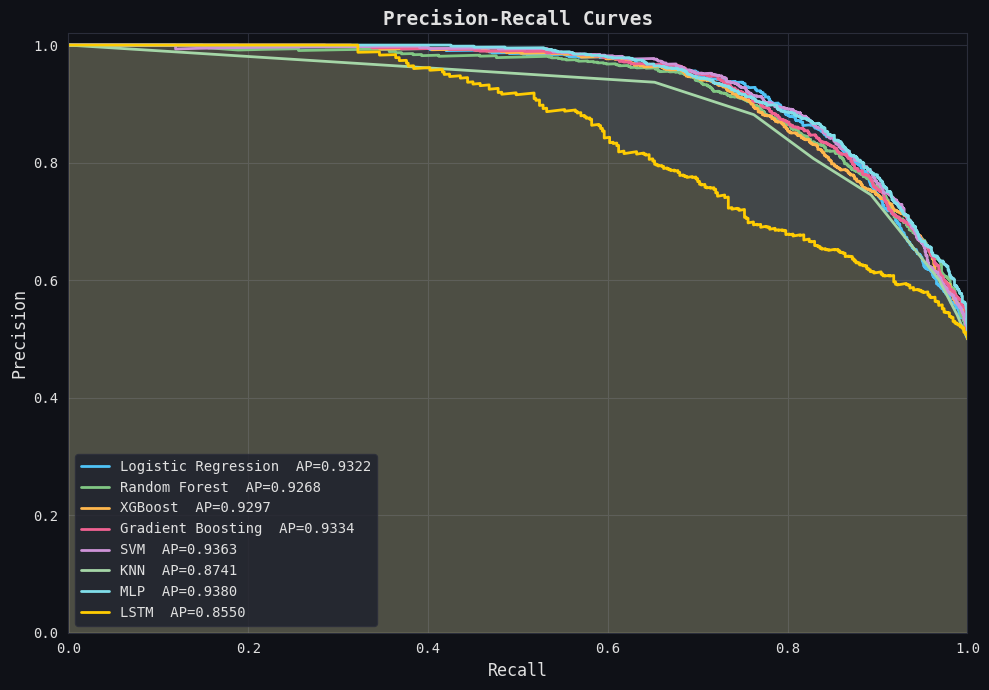

In [57]:
# ── VIZ 5: Precision-Recall Curves ───────────────────────────────────────────
fig, ax = plt.subplots(figsize=(10, 7))

for name in all_model_names:
    yt = ys_te if name == 'LSTM' else y_te
    yp = PROBS[name]
    prec, rec, _ = precision_recall_curve(yt, yp)
    ap = average_precision_score(yt, yp)
    c = MODEL_COLORS.get(name, '#AAAAAA')
    ax.fill_between(rec, prec, alpha=0.06, color=c)
    ax.plot(rec, prec, color=c, linewidth=2, label=f'{name}  AP={ap:.4f}')

ax.set_xlabel('Recall', fontsize=12)
ax.set_ylabel('Precision', fontsize=12)
ax.set_title('Precision-Recall Curves', fontsize=14, fontweight='bold')
ax.legend(loc='lower left', fontsize=10)
ax.set_xlim(0, 1); ax.set_ylim(0, 1.02)
plt.tight_layout()
plt.savefig('viz_05_precision_recall.png', dpi=150, bbox_inches='tight')
plt.show()

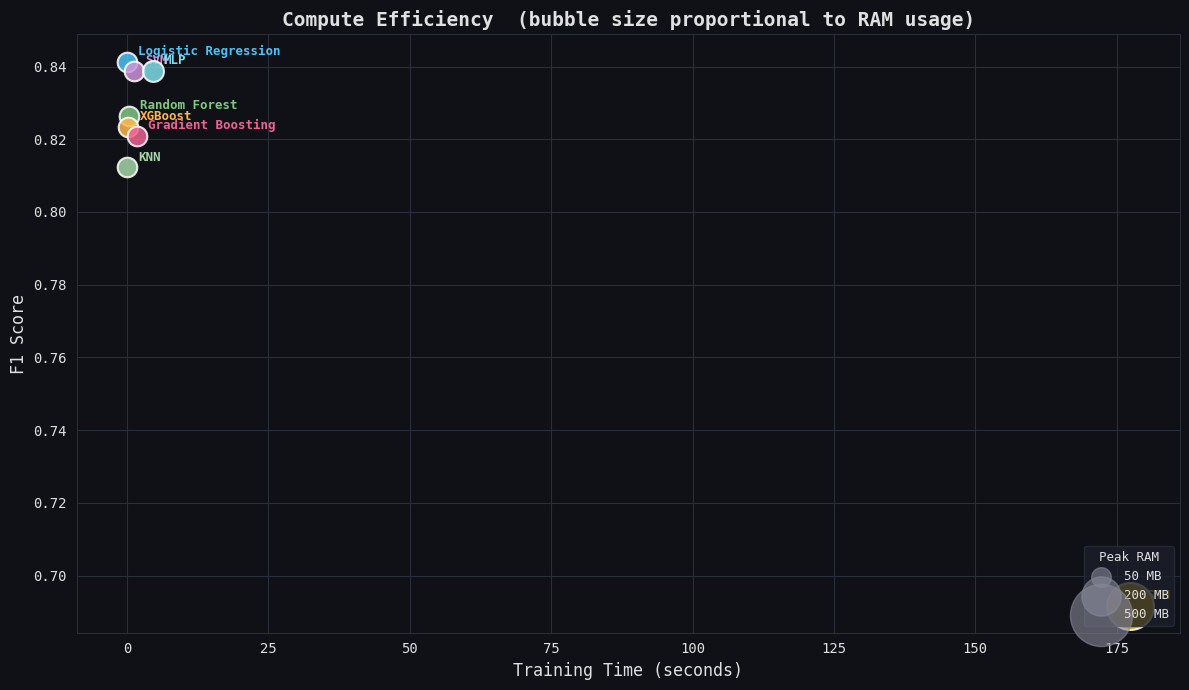

In [58]:
# ── VIZ 6: Compute Efficiency Bubble Chart ────────────────────────────────────
# X = training time, Y = F1, bubble size = memory
fig, ax = plt.subplots(figsize=(12, 7))

for name in all_model_names:
    t   = comp_df.loc[name, 'Time_s']
    mem = comp_df.loc[name, 'Mem_MB']
    f1  = res_df.loc[name, 'F1']
    c   = MODEL_COLORS.get(name, '#AAAAAA')
    size = max(mem, 50) * 4
    ax.scatter(t, f1, s=size, color=c, alpha=0.85, edgecolors='white',
               linewidths=1.5, zorder=5)
    ax.annotate(name, (t, f1),
                textcoords='offset points', xytext=(8, 5),
                fontsize=9, color=c, fontweight='bold')

ax.set_xlabel('Training Time (seconds)', fontsize=12)
ax.set_ylabel('F1 Score', fontsize=12)
ax.set_title('Compute Efficiency  (bubble size proportional to RAM usage)',
             fontsize=14, fontweight='bold')

# Legend for bubble size
for mb_val in [50, 200, 500]:
    ax.scatter([], [], s=mb_val * 4, color='#888899', alpha=0.6,
               label=f'{mb_val} MB')
ax.legend(title='Peak RAM', fontsize=9, title_fontsize=9, loc='lower right')

plt.tight_layout()
plt.savefig('viz_06_compute_bubble.png', dpi=150, bbox_inches='tight')
plt.show()

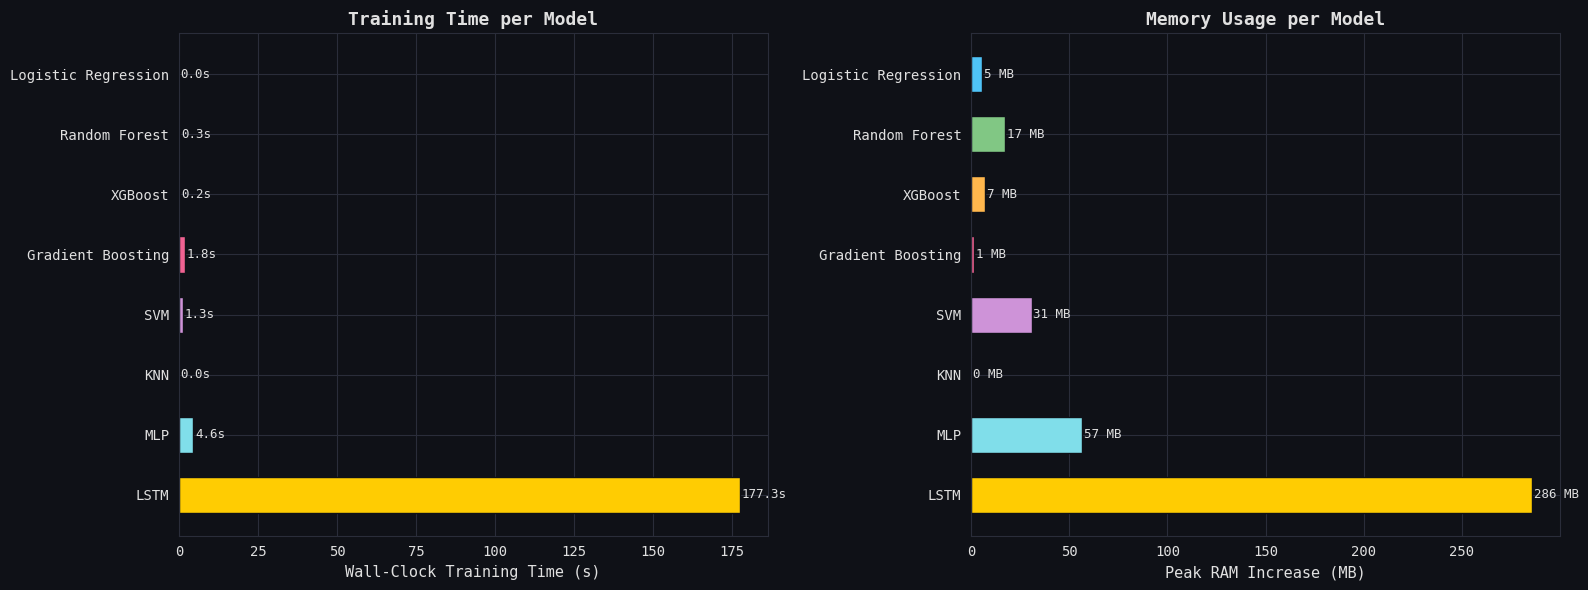

In [59]:
# ── VIZ 7: Training Time + Memory Side-by-Side ───────────────────────────────
names = list(comp_df.index)
colors_list = [MODEL_COLORS.get(n, '#AAAAAA') for n in names]
times  = comp_df['Time_s'].values
mems   = comp_df['Mem_MB'].values

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# Training time
bars1 = ax1.barh(names, times, color=colors_list, edgecolor='#0F1117', height=0.6)
for bar, v in zip(bars1, times):
    ax1.text(v + 0.5, bar.get_y() + bar.get_height()/2,
             f'{v:.1f}s', va='center', fontsize=9, color='#E0E0E0')
ax1.set_xlabel('Wall-Clock Training Time (s)', fontsize=11)
ax1.set_title('Training Time per Model', fontsize=13, fontweight='bold')
ax1.invert_yaxis()

# Memory
bars2 = ax2.barh(names, mems, color=colors_list, edgecolor='#0F1117', height=0.6)
for bar, v in zip(bars2, mems):
    ax2.text(v + 1, bar.get_y() + bar.get_height()/2,
             f'{v:.0f} MB', va='center', fontsize=9, color='#E0E0E0')
ax2.set_xlabel('Peak RAM Increase (MB)', fontsize=11)
ax2.set_title('Memory Usage per Model', fontsize=13, fontweight='bold')
ax2.invert_yaxis()

plt.tight_layout()
plt.savefig('viz_07_compute_bars.png', dpi=150, bbox_inches='tight')
plt.show()

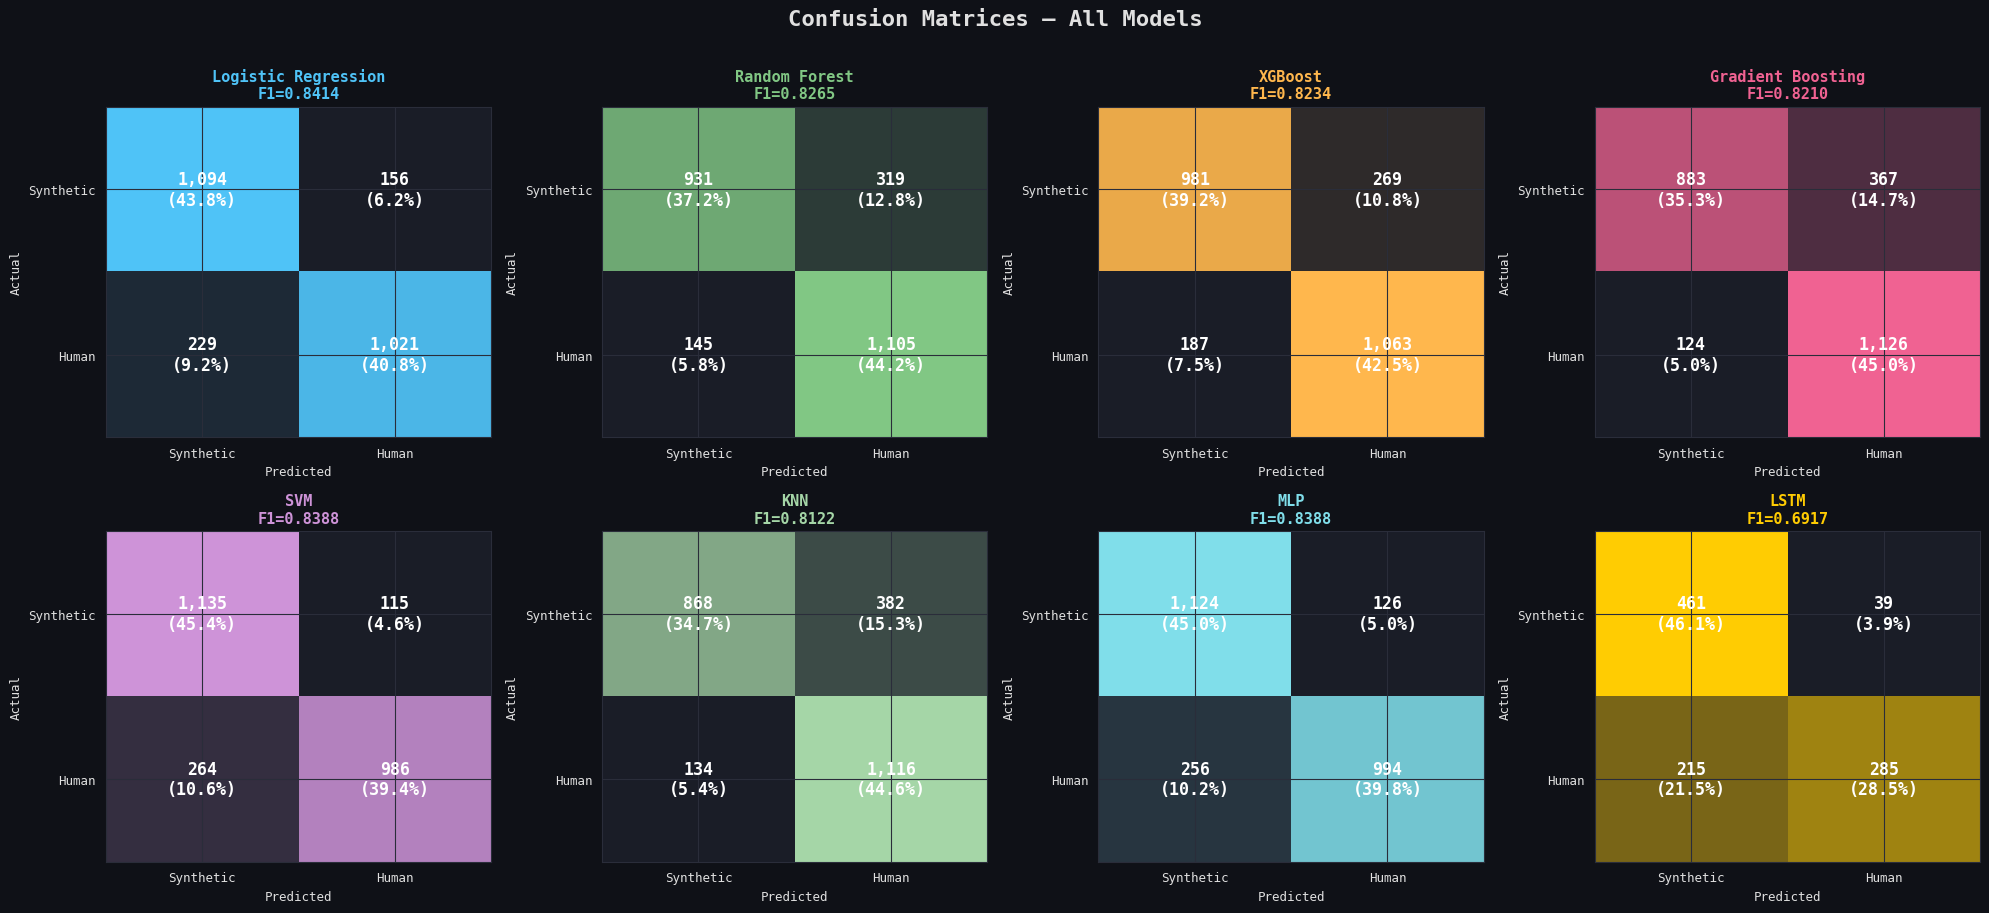

In [60]:
# ── VIZ 8: Confusion Matrix Gallery ──────────────────────────────────────────
ncols = 4
nrows = int(np.ceil(len(all_model_names) / ncols))
fig, axes = plt.subplots(nrows, ncols, figsize=(ncols * 5, nrows * 4.5))

for ax, name in zip(axes.flat, all_model_names):
    yt = ys_te if name == 'LSTM' else y_te
    yp = PREDS[name]
    cm = confusion_matrix(yt, yp)
    total = cm.sum()
    c = MODEL_COLORS.get(name, '#6C63FF')

    # Custom gradient cmap from dark to model color
    cm_cmap = LinearSegmentedColormap.from_list('mc', ['#1A1D27', c])
    ax.imshow(cm, cmap=cm_cmap, aspect='auto')

    for i in range(2):
        for j in range(2):
            v = cm[i, j]
            pct = v / total * 100
            ax.text(j, i, f'{v:,}\n({pct:.1f}%)',
                    ha='center', va='center', fontsize=12,
                    color='white', fontweight='bold')

    ax.set_xticks([0, 1]); ax.set_yticks([0, 1])
    ax.set_xticklabels(['Synthetic', 'Human'], fontsize=9)
    ax.set_yticklabels(['Synthetic', 'Human'], fontsize=9)
    ax.set_xlabel('Predicted', fontsize=9)
    ax.set_ylabel('Actual',    fontsize=9)
    f1v = res_df.loc[name, 'F1']
    ax.set_title(f'{name}\nF1={f1v:.4f}', fontsize=11, fontweight='bold', color=c)

for ax in list(axes.flat)[len(all_model_names):]:
    ax.set_visible(False)

fig.suptitle('Confusion Matrices — All Models', fontsize=16, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('viz_08_confusion_matrices.png', dpi=150, bbox_inches='tight')
plt.show()

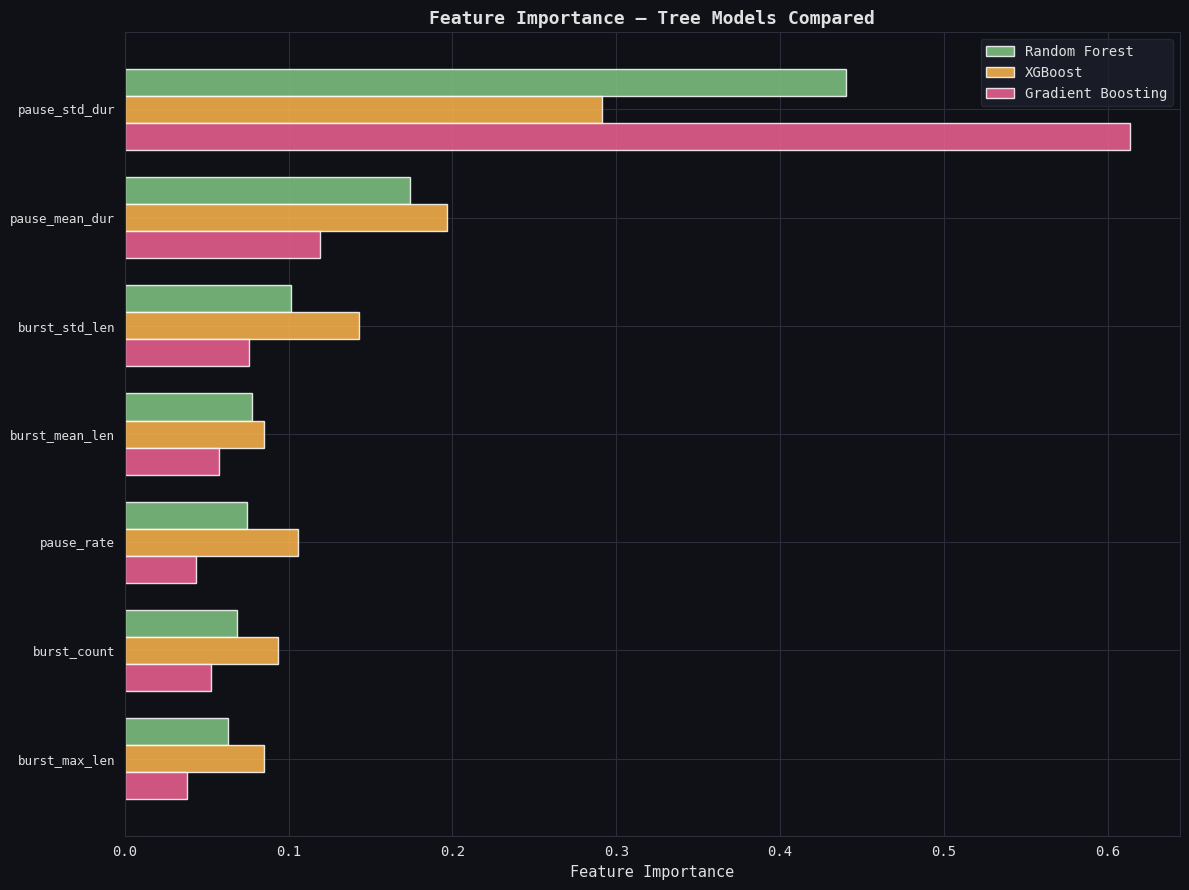

In [61]:
# ── VIZ 9: Feature Importance Comparison (tree models) ───────────────────────
tree_models = {n: MODELS[n] for n in ['Random Forest', 'XGBoost', 'Gradient Boosting']
               if n in MODELS}

importance_dfs = {}
for name, model in tree_models.items():
    importance_dfs[name] = pd.Series(
        model.feature_importances_, index=FEATURE_NAMES
    ).sort_values(ascending=False)

# Use union of top-10 from each
top_feats = list(dict.fromkeys(
    [f for imp in importance_dfs.values() for f in imp.head(10).index]
))[:20]

comp_matrix = pd.DataFrame(
    {name: imp.reindex(top_feats).fillna(0) for name, imp in importance_dfs.items()}
)

fig, ax = plt.subplots(figsize=(12, 9))
x  = np.arange(len(top_feats))
bw = 0.25

for i, (name, col) in enumerate(comp_matrix.items()):
    c = MODEL_COLORS.get(name, '#AAAAAA')
    ax.barh(x + i * bw, col.values, bw, label=name, color=c, alpha=0.85)

ax.set_yticks(x + bw); ax.set_yticklabels(top_feats, fontsize=9)
ax.invert_yaxis()
ax.set_xlabel('Feature Importance', fontsize=11)
ax.set_title('Feature Importance — Tree Models Compared', fontsize=13, fontweight='bold')
ax.legend(fontsize=10)
plt.tight_layout()
plt.savefig('viz_09_feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()

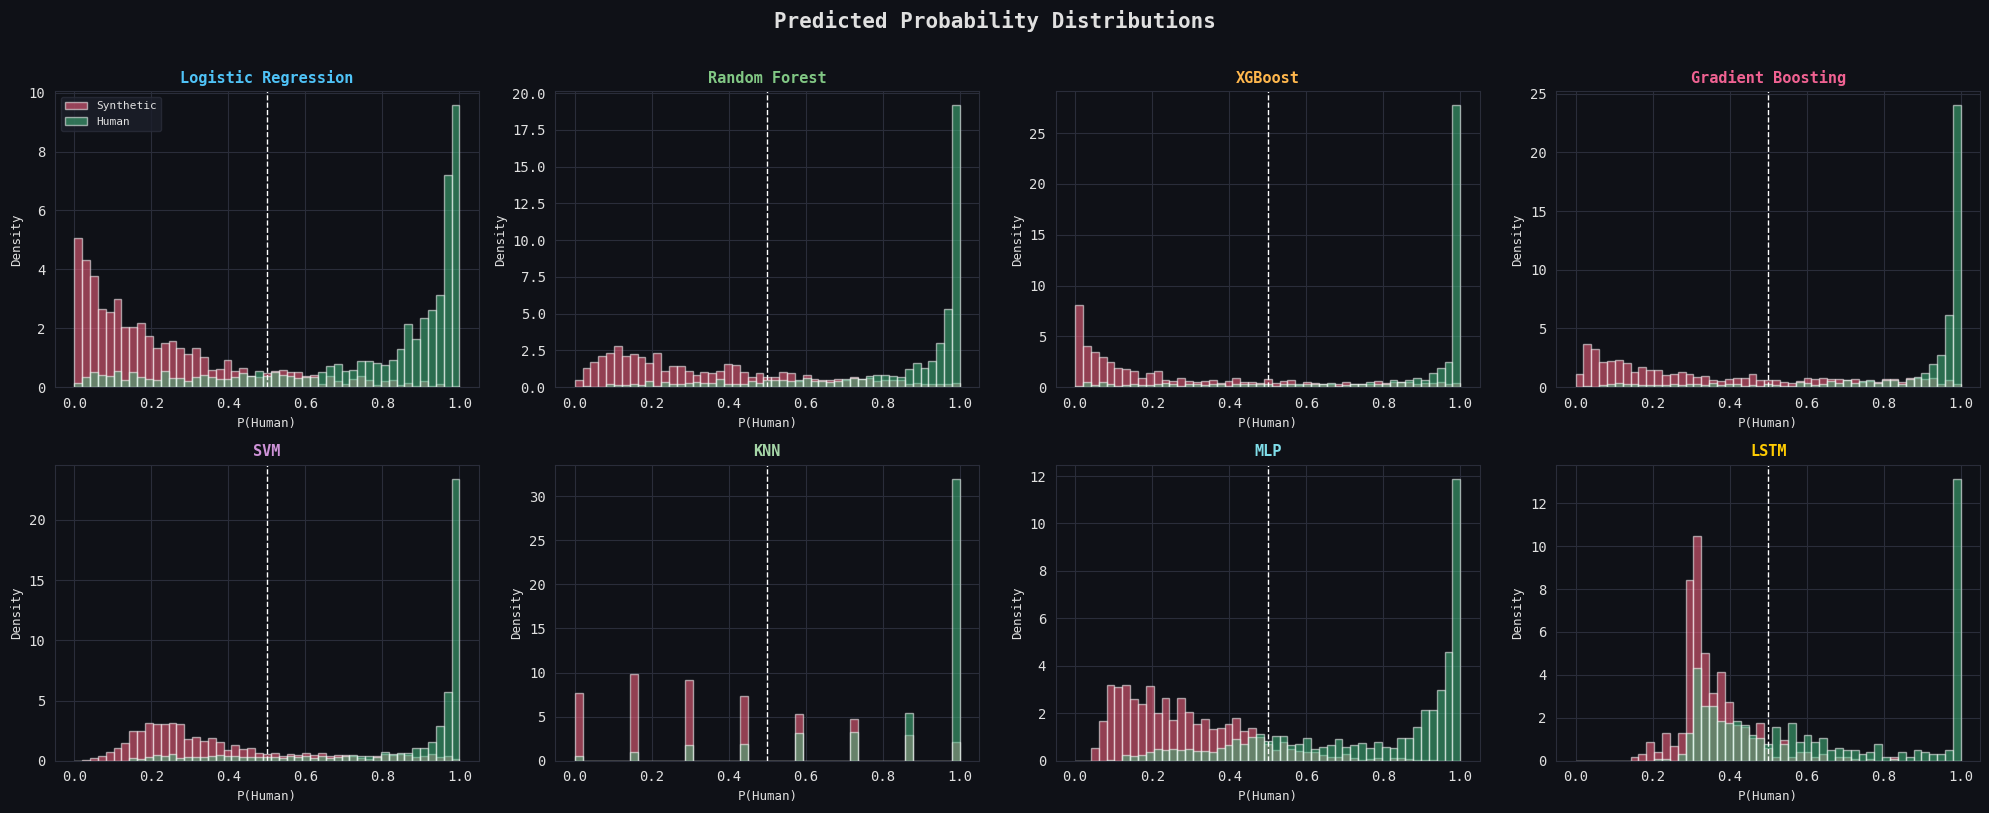

In [62]:
# ── VIZ 10: Score Distribution per Model ─────────────────────────────────────
ncols = 4
nrows = int(np.ceil(len(all_model_names) / ncols))
fig, axes = plt.subplots(nrows, ncols, figsize=(ncols * 5, nrows * 4))

for ax, name in zip(axes.flat, all_model_names):
    yt = ys_te if name == 'LSTM' else y_te
    yp = PROBS[name]
    c  = MODEL_COLORS.get(name, '#AAAAAA')

    bins = np.linspace(0, 1, 50)
    ax.hist(yp[yt == 0], bins=bins, alpha=0.55, color='#FF6584',
            label='Synthetic', density=True)
    ax.hist(yp[yt == 1], bins=bins, alpha=0.55, color='#43B97F',
            label='Human',    density=True)
    ax.axvline(0.5, color='white', linewidth=1, linestyle='--')
    ax.set_title(name, fontsize=11, fontweight='bold', color=c)
    ax.set_xlabel('P(Human)', fontsize=9)
    ax.set_ylabel('Density',  fontsize=9)
    if ax == axes.flat[0]:
        ax.legend(fontsize=8)

for ax in list(axes.flat)[len(all_model_names):]:
    ax.set_visible(False)

fig.suptitle('Predicted Probability Distributions', fontsize=15, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('viz_10_score_distributions.png', dpi=150, bbox_inches='tight')
plt.show()

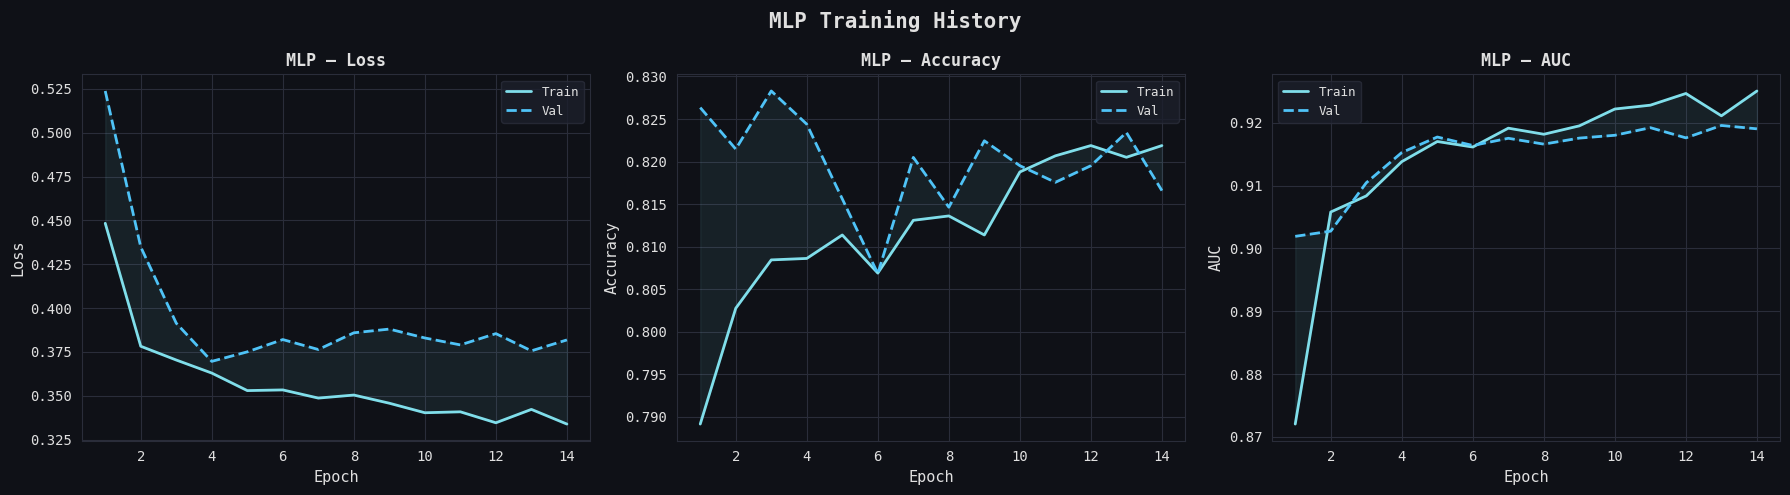

In [63]:
# ── VIZ 11: MLP Training History ─────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
hist_keys = [('loss', 'val_loss'), ('accuracy', 'val_accuracy'), ('auc', 'val_auc')]
titles    = ['Loss', 'Accuracy', 'AUC']

for ax, (tr_k, va_k), title in zip(axes, hist_keys, titles):
    if tr_k in mlp_history.history:
        ep = range(1, len(mlp_history.history[tr_k]) + 1)
        ax.plot(ep, mlp_history.history[tr_k],  color=PALETTE[5], linewidth=2, label='Train')
        ax.plot(ep, mlp_history.history[va_k],  color=PALETTE[0], linewidth=2,
                linestyle='--', label='Val')
        ax.fill_between(ep, mlp_history.history[tr_k],
                        mlp_history.history[va_k], alpha=0.08, color=PALETTE[5])
    ax.set_xlabel('Epoch', fontsize=11); ax.set_ylabel(title, fontsize=11)
    ax.set_title(f'MLP — {title}', fontsize=12, fontweight='bold')
    ax.legend(fontsize=9)

plt.suptitle('MLP Training History', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.savefig('viz_11_mlp_history.png', dpi=150, bbox_inches='tight')
plt.show()

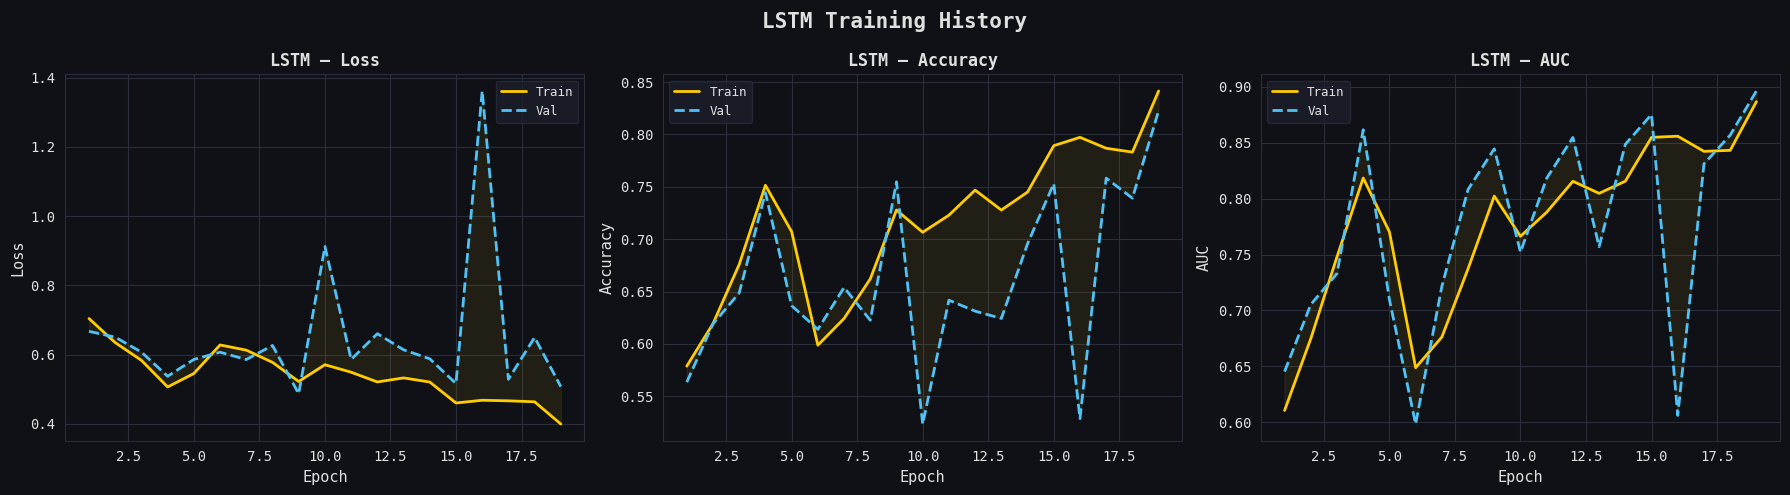

In [64]:
# ── VIZ 12: LSTM Training History ────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, (tr_k, va_k), title in zip(axes, hist_keys, titles):
    if tr_k in lstm_history.history:
        ep = range(1, len(lstm_history.history[tr_k]) + 1)
        ax.plot(ep, lstm_history.history[tr_k], color=PALETTE[6], linewidth=2, label='Train')
        ax.plot(ep, lstm_history.history[va_k], color=PALETTE[0], linewidth=2,
                linestyle='--', label='Val')
        ax.fill_between(ep, lstm_history.history[tr_k],
                        lstm_history.history[va_k], alpha=0.08, color=PALETTE[6])
    ax.set_xlabel('Epoch', fontsize=11); ax.set_ylabel(title, fontsize=11)
    ax.set_title(f'LSTM — {title}', fontsize=12, fontweight='bold')
    ax.legend(fontsize=9)

plt.suptitle('LSTM Training History', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.savefig('viz_12_lstm_history.png', dpi=150, bbox_inches='tight')
plt.show()

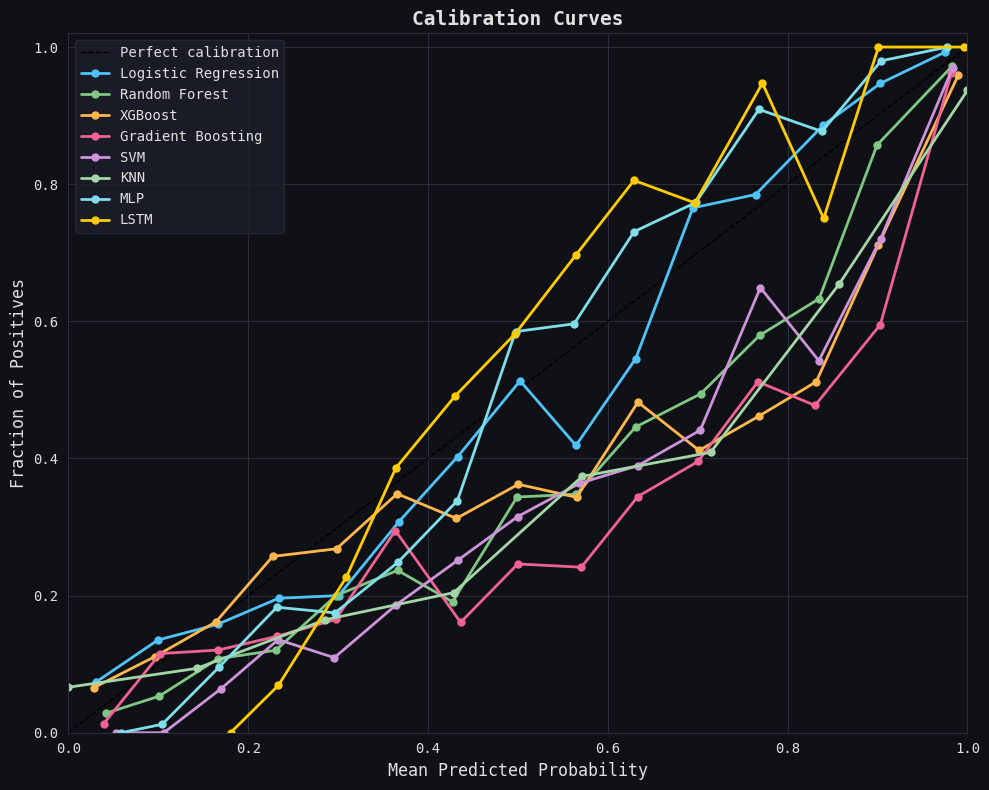

In [65]:
# ── VIZ 13: Calibration Curves ───────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(10, 8))
ax.plot([0, 1], [0, 1], 'k--', linewidth=1, label='Perfect calibration')

for name in all_model_names:
    yt = ys_te if name == 'LSTM' else y_te
    yp = PROBS[name]
    try:
        prob_true, prob_pred = calibration_curve(yt, yp, n_bins=15)
        c = MODEL_COLORS.get(name, '#AAAAAA')
        ax.plot(prob_pred, prob_true, 'o-', color=c, linewidth=2,
                markersize=5, label=name)
    except:
        pass

ax.set_xlabel('Mean Predicted Probability', fontsize=12)
ax.set_ylabel('Fraction of Positives',       fontsize=12)
ax.set_title('Calibration Curves',           fontsize=14, fontweight='bold')
ax.legend(fontsize=10)
ax.set_xlim(0, 1); ax.set_ylim(0, 1.02)
plt.tight_layout()
plt.savefig('viz_13_calibration.png', dpi=150, bbox_inches='tight')
plt.show()

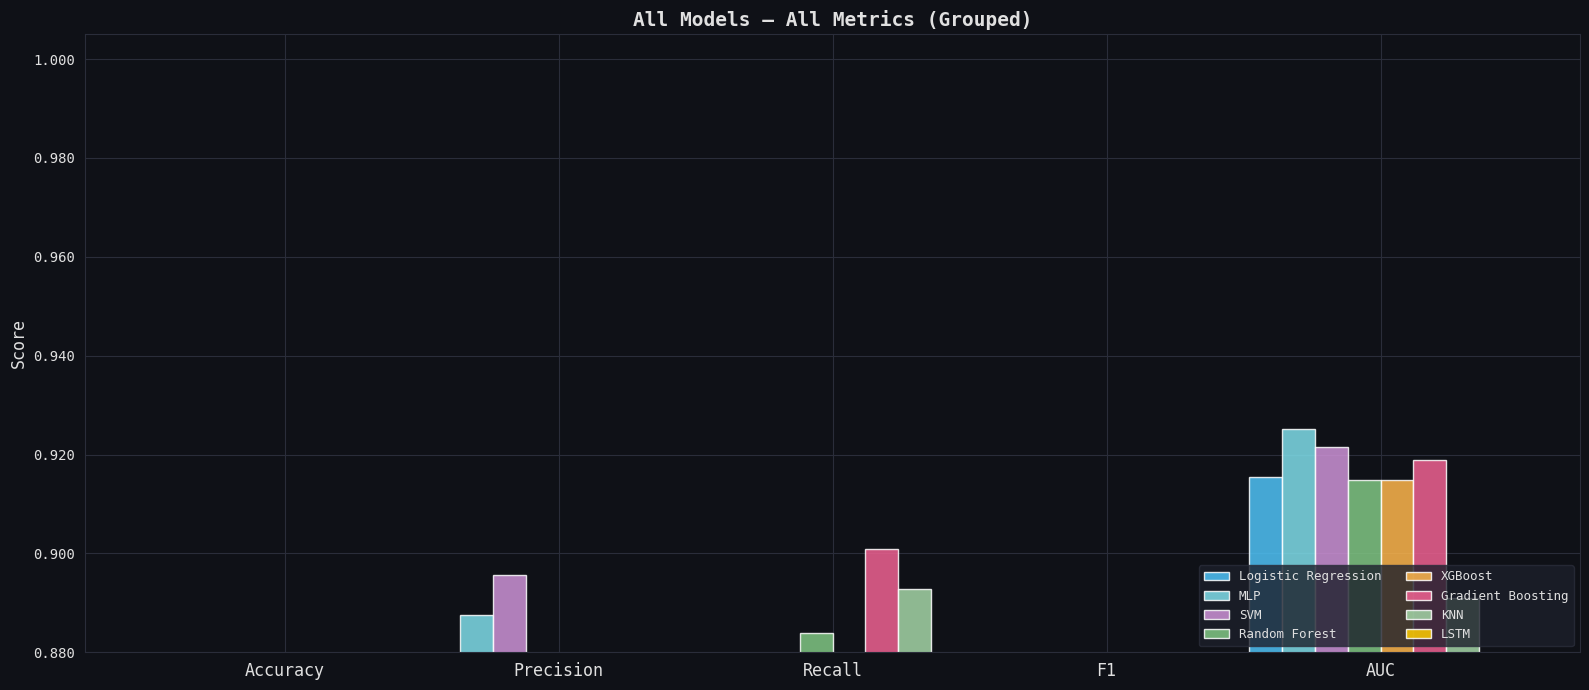

In [66]:
# ── VIZ 14: Grouped Bar — All Metrics ────────────────────────────────────────
metrics_bar = ['Accuracy', 'Precision', 'Recall', 'F1', 'AUC']
sorted_models = res_df.sort_values('F1', ascending=False).index.tolist()
n_models = len(sorted_models)
n_mets   = len(metrics_bar)
bw = 0.12
x  = np.arange(n_mets)

fig, ax = plt.subplots(figsize=(16, 7))

for i, name in enumerate(sorted_models):
    vals = [res_df.loc[name, m] for m in metrics_bar]
    offset = (i - n_models / 2) * bw + bw / 2
    c = MODEL_COLORS.get(name, '#AAAAAA')
    bars = ax.bar(x + offset, vals, bw, label=name, color=c, alpha=0.85)

ax.set_xticks(x); ax.set_xticklabels(metrics_bar, fontsize=12)
ax.set_ylim(0.88, 1.005)
ax.set_ylabel('Score', fontsize=12)
ax.set_title('All Models — All Metrics (Grouped)', fontsize=14, fontweight='bold')
ax.legend(loc='lower right', fontsize=9, ncol=2)
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f'{v:.3f}'))
plt.tight_layout()
plt.savefig('viz_14_grouped_bar.png', dpi=150, bbox_inches='tight')
plt.show()

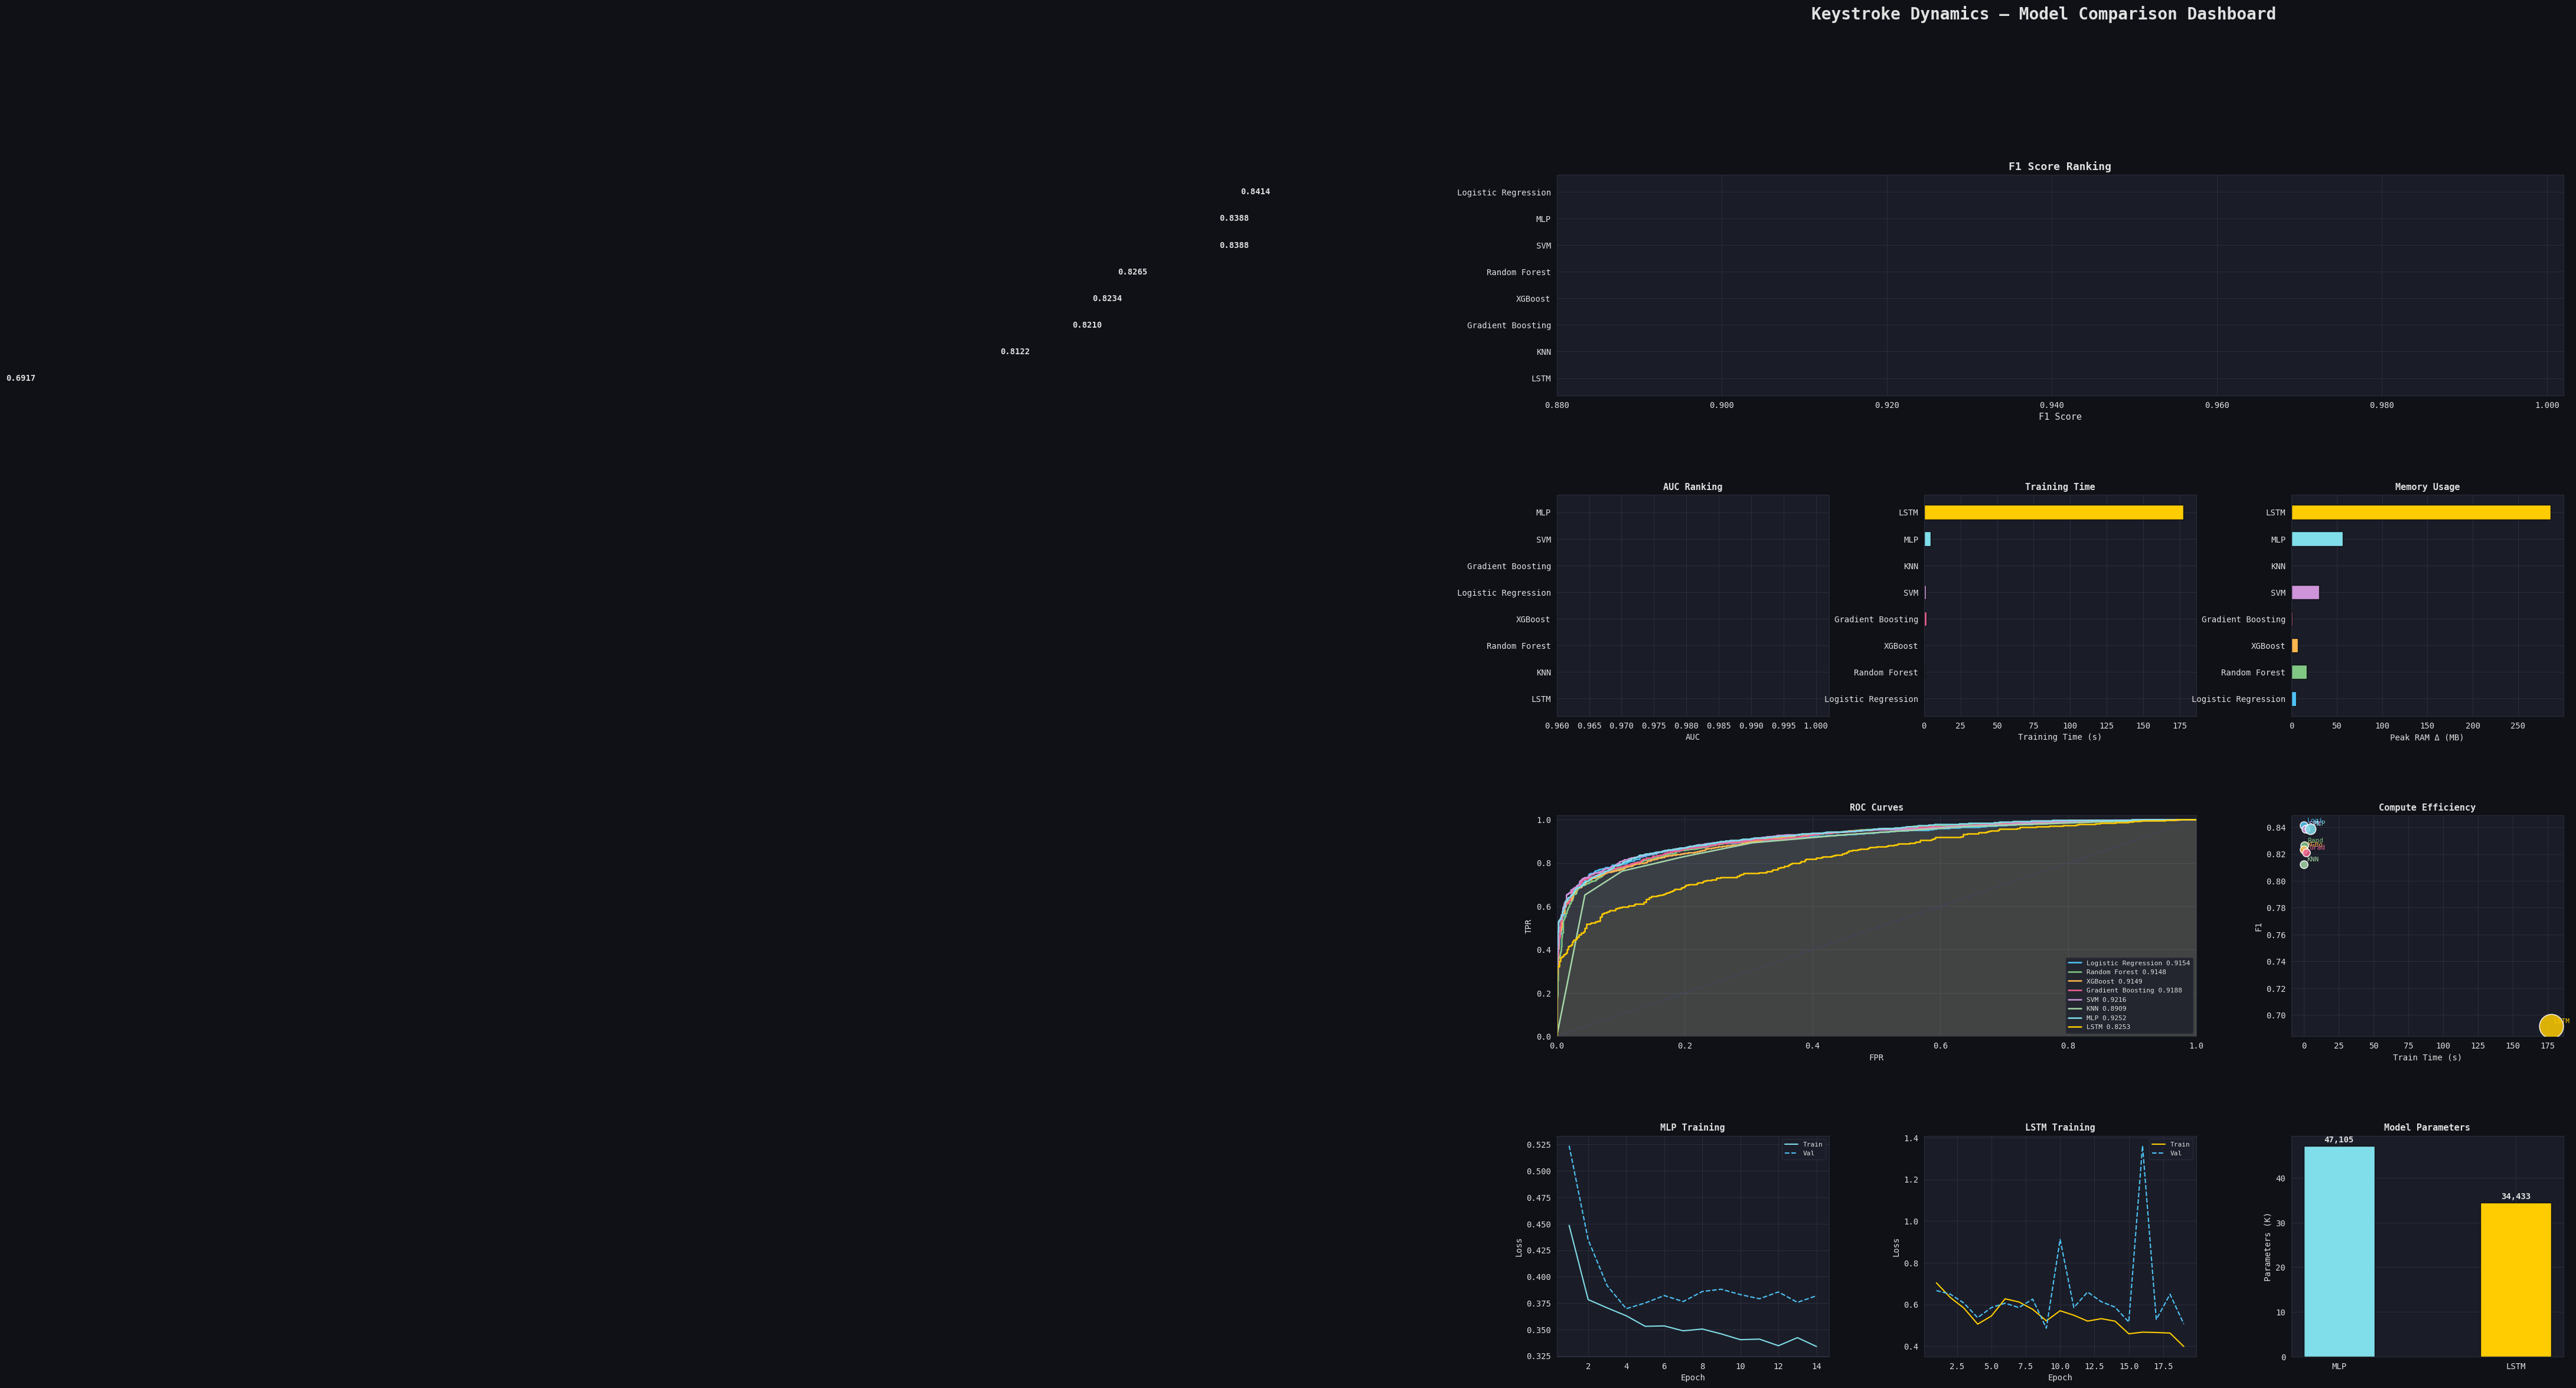

Dashboard saved.


In [67]:
# ── VIZ 15: Grand Dashboard ───────────────────────────────────────────────────
fig = plt.figure(figsize=(22, 26), facecolor='#0F1117')
fig.suptitle('Keystroke Dynamics — Model Comparison Dashboard',
             fontsize=20, fontweight='bold', color='#E0E0E0', y=0.99)

gs = gridspec.GridSpec(4, 3, figure=fig, hspace=0.45, wspace=0.35)

# ── Panel A: F1 horizontal bar ────────────────────────────────────────────────
axA = fig.add_subplot(gs[0, :])
sorted_r = res_df.sort_values('F1')
bars = axA.barh(
    sorted_r.index,
    sorted_r['F1'],
    color=[MODEL_COLORS.get(n, '#AAAAAA') for n in sorted_r.index],
    height=0.55, edgecolor='#0F1117'
)
axA.set_xlim(0.88, 1.002)
for bar, (_, row) in zip(bars, sorted_r.iterrows()):
    axA.text(bar.get_width() + 0.0003, bar.get_y() + bar.get_height()/2,
             f"{row['F1']:.4f}", va='center', fontsize=10,
             color=MODEL_COLORS.get(bar.get_label(), '#E0E0E0'), fontweight='bold')
axA.set_xlabel('F1 Score', fontsize=11)
axA.set_title('F1 Score Ranking', fontsize=13, fontweight='bold')
axA.set_facecolor('#1A1D27')
axA.xaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f'{v:.3f}'))

# ── Panel B: AUC bar ─────────────────────────────────────────────────────────
axB = fig.add_subplot(gs[1, 0])
sorted_auc = res_df.sort_values('AUC')
axB.barh(sorted_auc.index, sorted_auc['AUC'],
         color=[MODEL_COLORS.get(n, '#AAAAAA') for n in sorted_auc.index],
         height=0.55, edgecolor='#0F1117')
axB.set_xlim(0.96, 1.002)
axB.set_xlabel('AUC')
axB.set_title('AUC Ranking', fontsize=11, fontweight='bold')
axB.set_facecolor('#1A1D27')

# ── Panel C: Training time ────────────────────────────────────────────────────
axC = fig.add_subplot(gs[1, 1])
axC.barh(comp_df.index, comp_df['Time_s'],
         color=[MODEL_COLORS.get(n, '#AAAAAA') for n in comp_df.index],
         height=0.55, edgecolor='#0F1117')
axC.set_xlabel('Training Time (s)')
axC.set_title('Training Time', fontsize=11, fontweight='bold')
axC.set_facecolor('#1A1D27')

# ── Panel D: Memory ──────────────────────────────────────────────────────────
axD = fig.add_subplot(gs[1, 2])
axD.barh(comp_df.index, comp_df['Mem_MB'],
         color=[MODEL_COLORS.get(n, '#AAAAAA') for n in comp_df.index],
         height=0.55, edgecolor='#0F1117')
axD.set_xlabel('Peak RAM Δ (MB)')
axD.set_title('Memory Usage', fontsize=11, fontweight='bold')
axD.set_facecolor('#1A1D27')

# ── Panel E: ROC overlay ─────────────────────────────────────────────────────
axE = fig.add_subplot(gs[2, :2])
axE.plot([0, 1], [0, 1], '--', color='#444466', linewidth=1)
for name in all_model_names:
    yt = ys_te if name == 'LSTM' else y_te
    fpr, tpr, _ = roc_curve(yt, PROBS[name])
    auc = roc_auc_score(yt, PROBS[name])
    c = MODEL_COLORS.get(name, '#AAAAAA')
    axE.fill_between(fpr, tpr, alpha=0.04, color=c)
    axE.plot(fpr, tpr, color=c, linewidth=1.8, label=f'{name} {auc:.4f}')
axE.set_xlabel('FPR'); axE.set_ylabel('TPR')
axE.set_title('ROC Curves', fontsize=11, fontweight='bold')
axE.legend(fontsize=8, loc='lower right')
axE.set_facecolor('#1A1D27')
axE.set_xlim(0, 1); axE.set_ylim(0, 1.02)

# ── Panel F: Bubble (compute vs F1) ──────────────────────────────────────────
axF = fig.add_subplot(gs[2, 2])
for name in all_model_names:
    t   = comp_df.loc[name, 'Time_s']
    mem = comp_df.loc[name, 'Mem_MB']
    f1  = res_df.loc[name, 'F1']
    c   = MODEL_COLORS.get(name, '#AAAAAA')
    axF.scatter(t, f1, s=max(mem, 30) * 3, color=c, alpha=0.85,
                edgecolors='white', linewidths=1.2, zorder=5)
    axF.annotate(name[:4], (t, f1), textcoords='offset points',
                 xytext=(4, 4), fontsize=8, color=c)
axF.set_xlabel('Train Time (s)'); axF.set_ylabel('F1')
axF.set_title('Compute Efficiency', fontsize=11, fontweight='bold')
axF.set_facecolor('#1A1D27')

# ── Panel G: MLP loss history ─────────────────────────────────────────────────
axG = fig.add_subplot(gs[3, 0])
ep_mlp = range(1, len(mlp_history.history['loss']) + 1)
axG.plot(ep_mlp, mlp_history.history['loss'],     color=PALETTE[5], label='Train')
axG.plot(ep_mlp, mlp_history.history['val_loss'], color=PALETTE[0], linestyle='--', label='Val')
axG.set_xlabel('Epoch'); axG.set_ylabel('Loss')
axG.set_title('MLP Training', fontsize=11, fontweight='bold')
axG.legend(fontsize=8)
axG.set_facecolor('#1A1D27')

# ── Panel H: LSTM loss history ────────────────────────────────────────────────
axH = fig.add_subplot(gs[3, 1])
ep_lstm = range(1, len(lstm_history.history['loss']) + 1)
axH.plot(ep_lstm, lstm_history.history['loss'],     color=PALETTE[6], label='Train')
axH.plot(ep_lstm, lstm_history.history['val_loss'], color=PALETTE[0], linestyle='--', label='Val')
axH.set_xlabel('Epoch'); axH.set_ylabel('Loss')
axH.set_title('LSTM Training', fontsize=11, fontweight='bold')
axH.legend(fontsize=8)
axH.set_facecolor('#1A1D27')

# ── Panel I: Param counts ─────────────────────────────────────────────────────
axI = fig.add_subplot(gs[3, 2])
param_names  = ['MLP', 'LSTM']
param_counts = [
    mlp_model.count_params(),
    lstm_model.count_params()
]
param_colors = [MODEL_COLORS['MLP'], MODEL_COLORS['LSTM']]
bars_p = axI.bar(param_names, [p/1000 for p in param_counts],
                 color=param_colors, edgecolor='#0F1117', width=0.4)
for bar, cnt in zip(bars_p, param_counts):
    axI.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
             f'{cnt:,}', ha='center', va='bottom', fontsize=10, fontweight='bold')
axI.set_ylabel('Parameters (K)')
axI.set_title('Model Parameters', fontsize=11, fontweight='bold')
axI.set_facecolor('#1A1D27')

plt.savefig('viz_15_dashboard.png', dpi=150, bbox_inches='tight')
plt.show()
print('Dashboard saved.')

## Part 8 — Bot Synthesizers: The Difficulty Ladder

We implement **6 bot types** of increasing realism. All templates are derived from `bot_cal_pids` only — zero overlap with the training set.

### The difficulty ladder

| Level | Bot | Description |
|-------|-----|-------------|
| 1 | **ScriptedBot** | Constant HT=120ms, FT=80ms — trivially detectable (zero variance) |
| 2 | **PopulationBot** | Samples from population marginals — wrong per-user mean |
| 3 | **CalibratedBot** | Lognormal matching a specific user's mean±std from bot_cal — matches first two moments |
| 4 | **KDEBot** | Full KDE marginal matching — matches distribution shape, not just mean/std |
| 5 | **MarkovBot** | First-order transition matrix over HT/FT bins — adds temporal memory (lag-1 correlations) |
| 6 | **HMMBot** | 5-state Gaussian HMM on log(HT)/log(FT) — models latent cognitive states |

### Why most attacks still fail
Even **KDEBot** (correct marginals) is detectable because:
- The tabular feature set includes `ht_autocorr_1` and `ft_autocorr_1` — autocorrelation structure differs
- `key_entropy` exposes the narrow VK alphabet (A-Z only vs natural text)

**MarkovBot** and **HMMBot** fix the autocorrelation problem but still use a restricted VK alphabet.

### The `lognormal_from_moments` helper
Hold times are log-normally distributed (positive, right-skewed).
Given a raw mean `mu` and std `sigma`, we convert to lognormal parameters:
```
sigma2_ln = log(1 + (sigma/mu)^2)
mu_ln     = log(mu) - sigma2_ln/2
```
This ensures `E[X] = mu` and `Std[X] = sigma` exactly.

### Zero-leakage guarantee
All synthesizer templates (KDE kernels, Markov transition matrices, HMM parameters) are fitted
on `bot_cal_sessions` — participants that never appear in `train_pids`, `prob_cal_pids`, or `test_in_pids`.

In [68]:
# ── Load bot_cal sessions ─────────────────────────────────────────────────────
print('Loading bot_cal sessions...')
bot_cal_sessions = []
for fp in eda_rng.choice(bot_cal_files, min(3000, len(bot_cal_files)), replace=False):
    df = load_keystroke_file(fp)
    if df is not None and len(df) >= 20:
        bot_cal_sessions.append(df)
print(f'  {len(bot_cal_sessions)} bot_cal sessions')

bc_ht_means   = np.array([df['HT'].mean() for df in bot_cal_sessions])
bc_ht_stds    = np.array([df['HT'].std()  for df in bot_cal_sessions])
bc_ft_means   = np.array([df['FT'].mean() for df in bot_cal_sessions])
bc_ft_stds    = np.array([df['FT'].std()  for df in bot_cal_sessions])
bc_lengths    = np.array([len(df)         for df in bot_cal_sessions])
bc_templates  = list(zip(bc_ht_means, bc_ht_stds, bc_ft_means, bc_ft_stds))

_bc_ht_all = np.concatenate([df['HT'].values for df in bot_cal_sessions])
_bc_ft_all = np.concatenate([df['FT'].values for df in bot_cal_sessions if len(df)>1])
_bc_ht_all = _bc_ht_all[(_bc_ht_all > 5) & (_bc_ht_all < 2000)]
_bc_ft_all = _bc_ft_all[_bc_ft_all >= 0]

bc_ht_kde = gaussian_kde(_bc_ht_all[:20000])
bc_ft_kde = gaussian_kde(_bc_ft_all[:20000])

bc_rng = np.random.default_rng(PIPE_SEED + 99)

def _bc_len():
    return int(np.clip(bc_rng.choice(bc_lengths), 30, 600))

def lognormal_from_moments(mean, std):
    cv2 = (std / (mean + 1e-9)) ** 2
    sigma2 = np.log(1 + cv2)
    mu = np.log(mean + 1e-9) - sigma2 / 2
    return mu, np.sqrt(sigma2)

def bc_scripted(n=None):
    if n is None: n = _bc_len()
    ht = np.full(n, 120.0)
    ft = np.concatenate([[0.0], np.full(n-1, 80.0)])
    return pd.DataFrame({'VK': bc_rng.integers(65,91,n), 'HT': ht, 'FT': ft})

def bc_population(n=None):
    if n is None: n = _bc_len()
    mu_ht = float(bc_rng.choice(bc_ht_means))
    mu_ft = float(bc_rng.choice(bc_ft_means))
    ht = np.abs(bc_rng.normal(mu_ht, 20., n)).clip(5, 2000)
    ft = np.concatenate([[0.], np.abs(bc_rng.normal(mu_ft, 20., n-1)).clip(0, 3000)])
    return pd.DataFrame({'VK': bc_rng.integers(65,91,n), 'HT': ht, 'FT': ft})

def bc_calibrated(n=None):
    if n is None: n = _bc_len()
    idx = bc_rng.integers(0, len(bc_templates))
    mu_ht, sd_ht, mu_ft, sd_ft = bc_templates[idx]
    sd_ht = max(sd_ht, 5.); sd_ft = max(sd_ft, 5.)
    ln_mu_ht, ln_sg_ht = lognormal_from_moments(mu_ht, sd_ht)
    ln_mu_ft, ln_sg_ft = lognormal_from_moments(max(mu_ft,5.), sd_ft)
    ht = bc_rng.lognormal(ln_mu_ht, ln_sg_ht, n).clip(5, 2000)
    ft = np.concatenate([[0.], bc_rng.lognormal(ln_mu_ft, ln_sg_ft, n-1).clip(0, 3000)])
    return pd.DataFrame({'VK': bc_rng.integers(65,91,n), 'HT': ht, 'FT': ft})

def bc_kde(n=None):
    if n is None: n = _bc_len()
    ht = bc_ht_kde.resample(n, seed=int(bc_rng.integers(0, 2**31))).flatten().clip(5, 2000)
    ft_raw = bc_ft_kde.resample(n-1, seed=int(bc_rng.integers(0, 2**31))).flatten().clip(0, 3000)
    ft = np.concatenate([[0.], ft_raw])
    return pd.DataFrame({'VK': bc_rng.integers(65,91,n), 'HT': ht, 'FT': ft})

# ── MarkovBot ──────────────────────────────────────────────────────────────────
class MarkovBot:
    def __init__(self, n_ht=40, n_ft=40):
        self.n_ht, self.n_ft = n_ht, n_ft
    def fit(self, sessions):
        all_ht = np.concatenate([s['HT'].values for s in sessions])
        all_ft = np.concatenate([s['FT'].values[s['FT'].values > 0] for s in sessions])
        self.ht_edges = np.unique(np.percentile(all_ht, np.linspace(0,100,self.n_ht+1)))
        self.ft_edges = np.unique(np.percentile(all_ft, np.linspace(0,100,self.n_ft+1)))
        n_ht_bins = len(self.ht_edges)-1; n_ft_bins = len(self.ft_edges)-1
        ht_trans = np.ones((n_ht_bins, n_ht_bins))
        ft_trans = np.ones((n_ft_bins, n_ft_bins))
        for s in sessions:
            ht = s['HT'].values
            bi = np.clip(np.digitize(ht, self.ht_edges)-1, 0, n_ht_bins-1)
            for a,b in zip(bi[:-1], bi[1:]): ht_trans[a,b] += 1
            ft = s['FT'].values[s['FT'].values > 0]
            bi = np.clip(np.digitize(ft, self.ft_edges)-1, 0, n_ft_bins-1)
            for a,b in zip(bi[:-1], bi[1:]): ft_trans[a,b] += 1
        self.ht_T = ht_trans / ht_trans.sum(1, keepdims=True)
        self.ft_T = ft_trans / ft_trans.sum(1, keepdims=True)
        self.n_ht_bins = n_ht_bins; self.n_ft_bins = n_ft_bins
    def _sample_chain(self, T, edges, n, rng):
        out = []; state = rng.integers(0, len(T))
        for _ in range(n):
            lo = edges[state]; hi = edges[state+1] if state+1 < len(edges) else edges[-1]*1.1
            out.append(rng.uniform(lo, max(hi, lo+1e-3)))
            state = rng.choice(len(T), p=T[state])
        return np.array(out)
    def generate(self, n=None, rng=None):
        if rng is None: rng = bc_rng
        if n is None: n = _bc_len()
        ht = self._sample_chain(self.ht_T, self.ht_edges, n, rng).clip(5, 2000)
        ft_raw = self._sample_chain(self.ft_T, self.ft_edges, n-1, rng).clip(0, 3000)
        ft = np.concatenate([[0.], ft_raw])
        return pd.DataFrame({'VK': rng.integers(65,91,n), 'HT': ht, 'FT': ft})

# ── HMMBot ─────────────────────────────────────────────────────────────────────
class HMMBot:
    def __init__(self, n_components=5):
        self.n_components = n_components
        self.model = None
    def fit(self, sessions, max_sessions=800):
        rng_idx = np.random.default_rng(PIPE_SEED+7)
        sel = sessions[:max_sessions]
        X_list, lengths = [], []
        for s in sel:
            ht = s['HT'].values
            ft_v = s['FT'].values; ft_v = ft_v[ft_v > 0]
            mn = min(len(ht), len(ft_v))
            if mn < 5: continue
            X_list.append(np.column_stack([np.log1p(ht[:mn]), np.log1p(ft_v[:mn])]))
            lengths.append(mn)
        X = np.vstack(X_list).astype(np.float64)
        self.model = hmmlearn_hmm.GaussianHMM(
            n_components=self.n_components, covariance_type='full',
            n_iter=80, random_state=PIPE_SEED)
        self.model.fit(X, lengths)
        print(f'  HMMBot fitted on {len(lengths)} sessions')
    def generate(self, n=None, rng=None):
        if n is None: n = _bc_len()
        obs, _ = self.model.sample(n)
        ht = np.exp(obs[:, 0]).clip(5, 2000)
        ft_raw = np.exp(obs[1:, 1]).clip(0, 3000)
        ft = np.concatenate([[0.], ft_raw])
        return pd.DataFrame({'VK': np.random.randint(65,91,n), 'HT': ht, 'FT': ft})

# ── Fit temporal bots ──────────────────────────────────────────────────────────
markov_bot = MarkovBot(n_ht=40, n_ft=40)
markov_bot.fit(bot_cal_sessions)
print('MarkovBot fitted')

hmm_bot = HMMBot(n_components=5)
hmm_bot.fit(bot_cal_sessions)
print('HMMBot fitted')

BOT_FACTORIES = {
    'ScriptedBot':   bc_scripted,
    'PopulationBot': bc_population,
    'CalibratedBot': bc_calibrated,
    'KDEBot':        bc_kde,
    'MarkovBot':     lambda n=None: markov_bot.generate(n),
    'HMMBot':        lambda n=None: hmm_bot.generate(n),
}
print(f'\nAll {len(BOT_FACTORIES)} bot factories ready')

Loading bot_cal sessions...
  3000 bot_cal sessions
MarkovBot fitted
  HMMBot fitted on 800 sessions
HMMBot fitted

All 6 bot factories ready


## Part 9 — Production Pipeline

### Why sliding windows?

A single-session feature extractor works for offline analysis but fails for **continuous authentication**:
- Users don't type one "session" — they type continuously
- We need to make a decision after every N keystrokes (not wait for session end)
- Different window sizes trade latency vs confidence:
  - `window=200`: high confidence, ~20 seconds of typing
  - `window=50`: early warning, ~5 seconds of typing

### Window aggregation: consecutive-pair max-min
Rather than taking the maximum score over all windows (which fires on any single anomalous window), we use:
```
session_score = max( min(s[i], s[i+1]) )  for i in 0..N-2
```
This requires **two consecutive** high-confidence windows — much more robust to transient anomalies.

### Isotonic calibration
Raw XGBoost probabilities are often miscalibrated — e.g. the true positive rate at threshold=0.5 may be 99.77% rather than 50%. Isotonic regression (fitted on `prob_cal` sessions) maps raw scores to well-calibrated probabilities.

### The BotDetector class interface
```python
detector = BotDetector(model, scaler, feature_cols, swe, threshold=0.5)
scores = detector.window_scores(df)   # list of per-window scores
score  = detector.session_score(df)   # single session-level score
flag   = detector.predict(df)         # True if bot
```

### Class imbalance
At real-world bot prevalences (1-5%), precision collapses even at low FPR.
At P(bot)=1% with FPR=1%: only 50% of flagged sessions are actual bots (base rate neglect).

In [69]:
def pipe_extract_features(df):
    '''29-feature extractor for production pipeline windows.'''
    if df is None or len(df) < 5: return None
    ht = df['HT'].values.astype(float)
    ft = df['FT'].values.astype(float)
    ft_valid = ft[ft > 0]

    def autocorr(arr, lag=1):
        if len(arr) <= lag: return 0.0
        a = arr[:-lag] - arr.mean(); b = arr[lag:] - arr.mean()
        denom = (np.std(arr)**2) * len(a)
        return float(np.dot(a,b)/denom) if denom > 0 else 0.0

    def feat_block(arr, prefix):
        if len(arr) < 2:
            return {f'{prefix}_{k}': 0.0
                    for k in ['mean','std','median','iqr','skew','kurt','cv','p05','p95','log_mean','log_std']}
        log_arr = np.log1p(np.clip(arr, 0, None))
        q25, q75 = np.percentile(arr, [25,75])
        return {
            f'{prefix}_mean':     float(np.mean(arr)),
            f'{prefix}_std':      float(np.std(arr)),
            f'{prefix}_median':   float(np.median(arr)),
            f'{prefix}_iqr':      float(q75-q25),
            f'{prefix}_skew':     float(_skew(arr)) if len(arr)>3 else 0.0,
            f'{prefix}_kurt':     float(_kurt(arr)) if len(arr)>3 else 0.0,
            f'{prefix}_cv':       float(np.std(arr)/(np.mean(arr)+1e-8)),
            f'{prefix}_p05':      float(np.percentile(arr,5)),
            f'{prefix}_p95':      float(np.percentile(arr,95)),
            f'{prefix}_log_mean': float(np.mean(log_arr)),
            f'{prefix}_log_std':  float(np.std(log_arr)),
        }

    feats = {}
    feats.update(feat_block(ht, 'ht'))
    feats.update(feat_block(ft_valid if len(ft_valid)>=2 else ft, 'ft'))
    ht_diff = np.diff(ht)
    feats['ht_diff_mean'] = float(np.mean(np.abs(ht_diff))) if len(ht_diff) else 0.
    feats['ht_diff_std']  = float(np.std(ht_diff))          if len(ht_diff) else 0.
    feats['ht_autocorr_1'] = autocorr(ht, 1)
    feats['ft_autocorr_1'] = autocorr(ft_valid if len(ft_valid)>2 else ft, 1)
    feats['ht_too_consistent'] = float(np.mean(np.abs(ht - ht.mean()) < 5))
    med_ft = np.median(ft_valid) if len(ft_valid) else 1.
    q3_ht = np.percentile(ht, 75); iqr_ht = q3_ht - np.percentile(ht, 25)
    feats['ft_outlier_ratio'] = float(np.mean(ft > q3_ht + 1.5*iqr_ht)) if iqr_ht > 0 else 0.
    feats['pause_regularity'] = float(np.std(ft_valid)/np.mean(ft_valid)) if len(ft_valid) and np.mean(ft_valid)>0 else 0.
    return feats

class SlidingWindowExtractor:
    '''Extract overlapping fixed-size windows from a keystroke session.'''
    def __init__(self, window=200, step=50, min_keys=30):
        self.window   = window
        self.step     = step
        self.min_keys = min_keys
    def transform(self, df):
        results = []
        n = len(df)
        if n < self.min_keys: return results
        starts = list(range(0, n - self.window + 1, self.step))
        if not starts: starts = [0]
        for s in starts:
            win = df.iloc[s:s+self.window]
            feat = pipe_extract_features(win)
            if feat: results.append((s + self.window - 1, feat))
        return results

swe_full  = SlidingWindowExtractor(window=200, step=50,  min_keys=30)
swe_short = SlidingWindowExtractor(window=50,  step=25,  min_keys=20)

print('Loading train sessions for pipeline...')
pipe_train_sessions = []
for fp in eda_rng.choice([f for f in train_files_raw if 'HUMAN' in os.path.basename(f)],
                          min(2000, len(human_tr)), replace=False):
    df = load_keystroke_file(fp)
    if df is not None and len(df) >= 30:
        pipe_train_sessions.append(df)
print(f'  {len(pipe_train_sessions)} human train sessions')

def build_windowed_matrix(human_sessions, bot_factories, swe, n_bot_per_type=300):
    rows = []
    for df in human_sessions:
        for _, feat in swe.transform(df):
            feat['label'] = 0; rows.append(feat)
    for nm, fn in bot_factories.items():
        gen = 0
        while gen < n_bot_per_type:
            df = fn()
            for _, feat in swe.transform(df):
                feat['label'] = 1; rows.append(feat)
                gen += 1
                if gen >= n_bot_per_type: break
    df_out = pd.DataFrame(rows).fillna(0)
    h = (df_out['label']==0).sum(); b = (df_out['label']==1).sum()
    print(f'  {h:,} human + {b:,} bot windows')
    return df_out

print('\nBuilding full-window training matrix...')
df_pw = build_windowed_matrix(pipe_train_sessions, BOT_FACTORIES, swe_full, n_bot_per_type=300)
print(f'Matrix shape: {df_pw.shape}')

Loading train sessions for pipeline...
  1830 human train sessions

Building full-window training matrix...
  24,856 human + 1,800 bot windows
Matrix shape: (26656, 30)


In [70]:
pipe_cols = [c for c in df_pw.columns if c != 'label']
X_pw = df_pw[pipe_cols].values
y_pw = df_pw['label'].values
pipe_sc = StandardScaler()
X_pw_s  = pipe_sc.fit_transform(X_pw)

pipe_base = XGBClassifier(n_estimators=300, max_depth=6, learning_rate=0.1,
                           random_state=PIPE_SEED, eval_metric='logloss', verbosity=0)
pipe_base.fit(X_pw_s, y_pw)
print('Base XGB trained')

# ── Probability calibration ───────────────────────────────────────────────────
print('Loading prob_cal sessions...')
prob_cal_sessions = []
for fp in [f for f in prob_cal_files if 'HUMAN' in os.path.basename(f)][:1000]:
    df = load_keystroke_file(fp)
    if df is not None and len(df) >= 30:
        prob_cal_sessions.append(df)
print(f'  {len(prob_cal_sessions)} prob_cal sessions')

cal_rows = []
for df in prob_cal_sessions[:500]:
    for _, feat in swe_full.transform(df):
        feat['label'] = 0; cal_rows.append(feat)
for nm, fn in BOT_FACTORIES.items():
    gen = 0
    while gen < 80:
        df = fn()
        for _, feat in swe_full.transform(df):
            feat['label'] = 1; cal_rows.append(feat)
            gen += 1
            if gen >= 80: break

df_cal_tmp = pd.DataFrame(cal_rows).fillna(0)
for c in pipe_cols:
    if c not in df_cal_tmp.columns: df_cal_tmp[c] = 0.
X_cal_s = pipe_sc.transform(df_cal_tmp[pipe_cols].values)
y_cal    = df_cal_tmp['label'].values

# sklearn >= 1.4 removed cv='prefit'; manual isotonic calibration on pre-fitted model
from sklearn.isotonic import IsotonicRegression as _IsoReg
_iso = _IsoReg(out_of_bounds='clip')
_iso.fit(pipe_base.predict_proba(X_cal_s)[:, 1], y_cal)

class _CalibratedModel:
    """Pre-fitted model + isotonic calibration layer (semantically equiv. to cv='prefit')."""
    def __init__(self, base, calibrator):
        self.base = base; self.calibrator = calibrator
    def predict_proba(self, X):
        p = self.base.predict_proba(X)[:, 1]
        c = self.calibrator.predict(p).clip(0, 1)
        return np.column_stack([1 - c, c])
    def predict(self, X):
        return (self.predict_proba(X)[:, 1] >= 0.5).astype(int)

pipe_cal = _CalibratedModel(pipe_base, _iso)

bs_base = brier_score_loss(y_cal, pipe_base.predict_proba(X_cal_s)[:,1])
bs_cal  = brier_score_loss(y_cal, pipe_cal.predict_proba(X_cal_s)[:,1])
print(f'Brier score: base={bs_base:.4f}  calibrated={bs_cal:.4f}  (lower=better)')

# ── BotDetector class ─────────────────────────────────────────────────────────
class BotDetector:
    '''
    Production sliding-window bot detector.
    Uses consecutive-pair aggregation: session score = max(min(s[i], s[i+1])).
    This is more conservative than max-window - requires two consecutive high-confidence windows.
    '''
    def __init__(self, model, scaler, cols, swe, threshold=0.5):
        self.model     = model
        self.scaler    = scaler
        self.cols      = cols
        self.swe       = swe
        self.threshold = threshold

    def window_scores(self, df):
        results = []
        for _, feat in self.swe.transform(df):
            row = pd.DataFrame([feat])
            for c in self.cols:
                if c not in row.columns: row[c] = 0.
            x = self.scaler.transform(row[self.cols].fillna(0).values)
            results.append(float(self.model.predict_proba(x)[0,1]))
        return results

    def session_score(self, df):
        scores = self.window_scores(df)
        if not scores:   return 0.
        if len(scores)==1: return scores[0]
        return max(min(scores[i], scores[i+1]) for i in range(len(scores)-1))

    def predict(self, df):
        return self.session_score(df) >= self.threshold

bot_detector = BotDetector(pipe_cal, pipe_sc, pipe_cols, swe_full, threshold=0.5)
print('BotDetector ready')

Base XGB trained
Loading prob_cal sessions...
  708 prob_cal sessions
Brier score: base=0.0007  calibrated=0.0004  (lower=better)
BotDetector ready


Scoring test sessions (in-distribution)...
Session AUC (in-dist): 0.9999
EER: 0.14%  at threshold 0.4553

Precision at FPR=1% (TPR=99.7%, threshold=0.2000):
  P(bot)= 50.0%: precision= 99.0% | tp=4986 fp=50
  P(bot)= 10.0%: precision= 91.7% | tp=997 fp=90
  P(bot)=  5.0%: precision= 84.0% | tp=498 fp=95
  P(bot)=  2.0%: precision= 67.1% | tp=199 fp=98
  P(bot)=  1.0%: precision= 50.2% | tp=99 fp=99
  P(bot)=  0.5%: precision= 33.4% | tp=49 fp=99
  P(bot)=  0.1%: precision=  9.1% | tp=9 fp=99


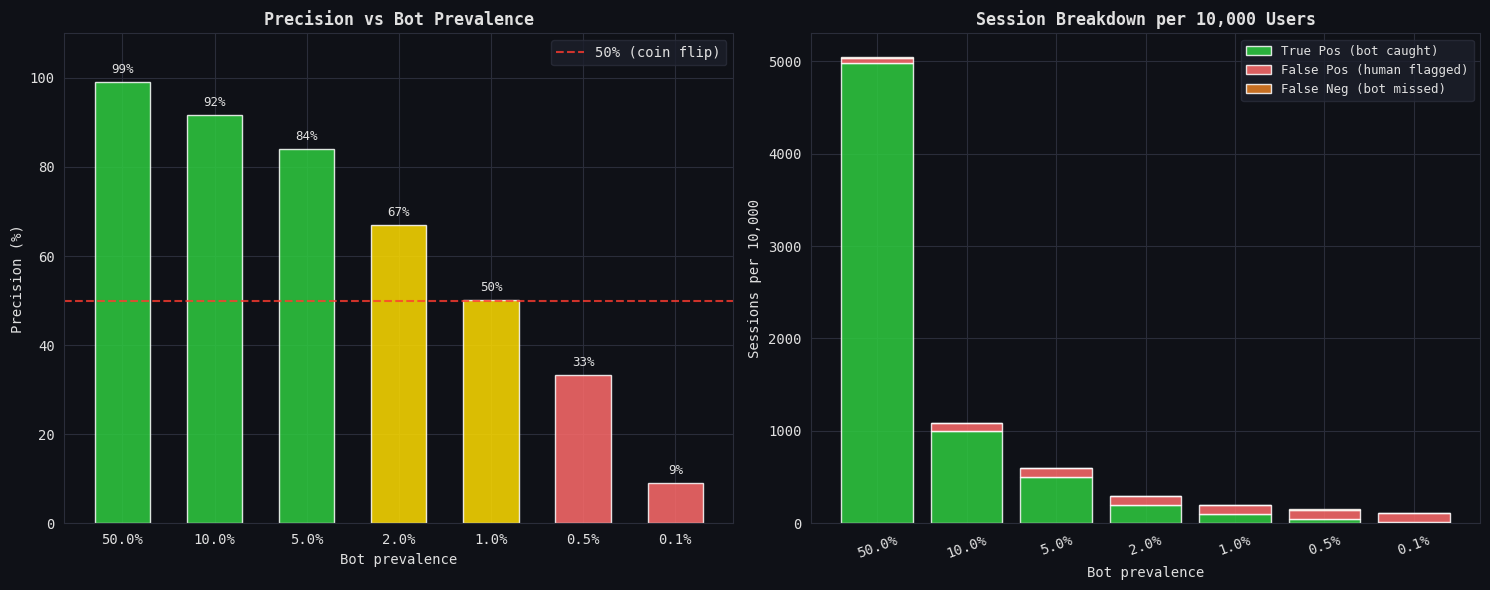

In [71]:
print('Scoring test sessions (in-distribution)...')
test_in_sessions = []
for fp in human_te[:400]:
    df = load_keystroke_file(fp)
    if df is not None and len(df)>=80:
        test_in_sessions.append(df)

human_sess_scores = [bot_detector.session_score(df) for df in test_in_sessions[:300]]
bot_sess_scores   = []
for nm, fn in BOT_FACTORIES.items():
    for _ in range(60):
        bot_sess_scores.append(bot_detector.session_score(fn()))

h_scores = np.array(human_sess_scores)
b_scores  = np.array(bot_sess_scores)
all_scores_sess = np.concatenate([h_scores, b_scores])
all_labels_sess = np.array([0]*len(h_scores) + [1]*len(b_scores))
fpr_s, tpr_s, thr_s = roc_curve(all_labels_sess, all_scores_sess)
session_auc = roc_auc_score(all_labels_sess, all_scores_sess)
print(f'Session AUC (in-dist): {session_auc:.4f}')

far_s = fpr_s; frr_s = 1 - tpr_s
eer_idx   = np.argmin(np.abs(far_s - frr_s))
eer       = (far_s[eer_idx] + frr_s[eer_idx]) / 2
eer_thresh = thr_s[eer_idx] if eer_idx < len(thr_s) else thr_s[-1]
print(f'EER: {eer*100:.2f}%  at threshold {eer_thresh:.4f}')
bot_detector.threshold = eer_thresh

# ── Class imbalance precision analysis ────────────────────────────────────────
target_fpr  = 0.01
fpr_idx     = min(np.searchsorted(fpr_s, target_fpr), len(thr_s)-1)
chosen_tpr  = tpr_s[min(fpr_idx, len(tpr_s)-1)]
chosen_thresh = thr_s[fpr_idx]

prevalences = [0.50, 0.10, 0.05, 0.02, 0.01, 0.005, 0.001]
prec_results = []
print(f'\nPrecision at FPR=1% (TPR={chosen_tpr*100:.1f}%, threshold={chosen_thresh:.4f}):')
for P in prevalences:
    prec = (chosen_tpr * P) / (chosen_tpr * P + target_fpr * (1-P) + 1e-12)
    n_bots = int(10000*P); n_humans = 10000 - n_bots
    tp = int(n_bots*chosen_tpr); fp = int(n_humans*target_fpr)
    prec_results.append({'prevalence':P, 'precision':prec, 'tp':tp, 'fp':fp})
    print(f'  P(bot)={P*100:5.1f}%: precision={prec*100:5.1f}% | tp={tp} fp={fp}')

# ── VIZ: Precision vs Prevalence ────────────────────────────────────────────
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15,6))
prev_labels = [f'{p["prevalence"]*100:.1f}%' for p in prec_results]
precisions  = [r['precision']*100 for r in prec_results]
bar_colors  = ['#2ECC40' if p>80 else ('#FFDC00' if p>50 else '#FF6B6B') for p in precisions]
ax1.bar(prev_labels, precisions, color=bar_colors, alpha=0.85, width=0.6)
ax1.axhline(50, color='#FF3B30', lw=1.5, ls='--', alpha=0.8, label='50% (coin flip)')
ax1.set_xlabel('Bot prevalence'); ax1.set_ylabel('Precision (%)')
ax1.set_title('Precision vs Bot Prevalence', fontweight='bold')
ax1.legend(); ax1.set_ylim(0,110)
for bar, prec in zip(ax1.patches, precisions):
    ax1.text(bar.get_x()+bar.get_width()/2, bar.get_height()+2, f'{prec:.0f}%', ha='center', fontsize=9)

x_pos = np.arange(len(prec_results))
tps = [r['tp'] for r in prec_results]; fps = [r['fp'] for r in prec_results]
fns = [int(10000*r['prevalence']) - r['tp'] for r in prec_results]
ax2.bar(x_pos, tps, label='True Pos (bot caught)',    color='#2ECC40', alpha=0.85)
ax2.bar(x_pos, fps, bottom=tps, label='False Pos (human flagged)', color='#FF6B6B', alpha=0.85)
ax2.bar(x_pos, fns, bottom=[t+f for t,f in zip(tps,fps)], label='False Neg (bot missed)', color='#E67E22', alpha=0.85)
ax2.set_xticks(x_pos); ax2.set_xticklabels(prev_labels, rotation=20)
ax2.set_xlabel('Bot prevalence'); ax2.set_ylabel('Sessions per 10,000')
ax2.set_title('Session Breakdown per 10,000 Users', fontweight='bold')
ax2.legend(fontsize=9)
plt.tight_layout()
plt.savefig('viz_class_imbalance.png', dpi=150, bbox_inches='tight')
plt.show()

Scoring cross-dataset test sessions (LSIA+KM)...
  800 out-of-distribution sessions

Cross-dataset AUC:
  LSIA: AUC=0.9986  (n_human=721)
  KM: AUC=0.9979  (n_human=79)


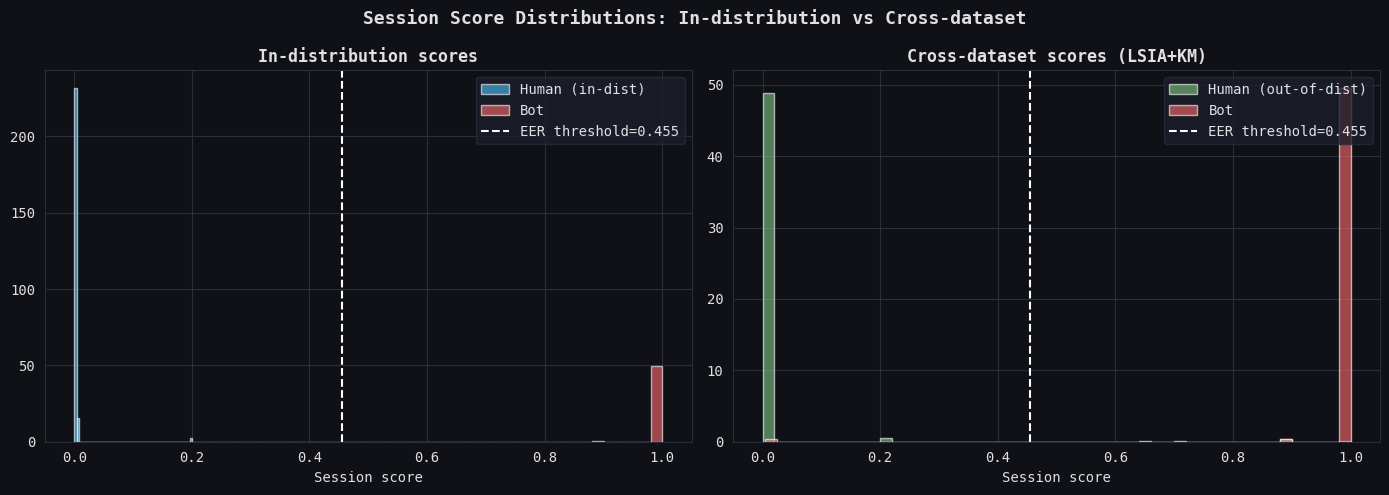

In [72]:
print('Scoring cross-dataset test sessions (LSIA+KM)...')
test_out_sessions = []
for fp in test_files_out[:800]:
    df = load_keystroke_file(fp)
    if df is not None and len(df)>=80:
        test_out_sessions.append((get_dataset(fp), df))
print(f'  {len(test_out_sessions)} out-of-distribution sessions')

h_out_scores = [(ds, bot_detector.session_score(df)) for ds, df in test_out_sessions]
b_out_scores  = []
for nm, fn in BOT_FACTORIES.items():
    for _ in range(50):
        b_out_scores.append(bot_detector.session_score(fn()))
b_out_arr = np.array(b_out_scores)

print('\nCross-dataset AUC:')
for ds in ['LSIA','KM']:
    h_sc = np.array([s for d,s in h_out_scores if d==ds])
    if len(h_sc) < 10:
        print(f'  {ds}: insufficient ({len(h_sc)} sessions)'); continue
    all_s  = np.concatenate([h_sc, b_out_arr])
    all_l  = np.array([0]*len(h_sc) + [1]*len(b_out_arr))
    auc_od = roc_auc_score(all_l, all_s)
    print(f'  {ds}: AUC={auc_od:.4f}  (n_human={len(h_sc)})')

# VIZ: in-dist vs cross-dataset score distributions
fig, axes = plt.subplots(1,2, figsize=(14,5))
axes[0].hist(h_scores, bins=50, alpha=0.6, color='#4FC3F7', label='Human (in-dist)', density=True)
axes[0].hist(b_scores, bins=50, alpha=0.6, color='#FF6B6B', label='Bot',              density=True)
axes[0].axvline(eer_thresh, color='white', lw=1.5, ls='--', label=f'EER threshold={eer_thresh:.3f}')
axes[0].set_title('In-distribution scores', fontweight='bold')
axes[0].legend(); axes[0].set_xlabel('Session score')

h_all_out = np.array([s for _,s in h_out_scores])
axes[1].hist(h_all_out, bins=50, alpha=0.6, color='#81C784', label='Human (out-of-dist)', density=True)
axes[1].hist(b_out_arr,  bins=50, alpha=0.6, color='#FF6B6B', label='Bot',                 density=True)
axes[1].axvline(eer_thresh, color='white', lw=1.5, ls='--', label=f'EER threshold={eer_thresh:.3f}')
axes[1].set_title('Cross-dataset scores (LSIA+KM)', fontweight='bold')
axes[1].legend(); axes[1].set_xlabel('Session score')
plt.suptitle('Session Score Distributions: In-distribution vs Cross-dataset', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('viz_cross_dataset.png', dpi=150, bbox_inches='tight')
plt.show()

In [73]:
# ── OOD tabular evaluation: all 8 models on LSIA+KM ─────────────────────────
print('=== OOD CROSS-TEXT EVALUATION: All 8 models on LSIA+KM ===')
print('Train=PROSODY (GAY/GUN/REVIEW), Test=LSIA+KM — true cross-text test\n')

from sklearn.metrics import roc_auc_score, f1_score
import numpy as np

# 1. Extract 7 burst-pause features from OOD human sessions
ood_human_feats, ood_human_ds = [], []
for fp in test_files_out:
    df = load_keystroke_file(fp)
    if df is None or len(df) < 5:
        continue
    feat = extract_features(df)
    if feat is None:
        continue
    row = [feat.get(k, 0.0) for k in FEATURE_NAMES]
    if any(np.isnan(v) or np.isinf(v) for v in row):
        continue
    ood_human_feats.append(row)
    ood_human_ds.append(get_dataset(fp))

# 2. Generate bot features for OOD evaluation
ood_bot_feats = []
for nm, fn in BOT_FACTORIES.items():
    for _ in range(300):
        try:
            df_bot = fn()
            feat = extract_features(df_bot)
            if feat is None: continue
            row = [feat.get(k, 0.0) for k in FEATURE_NAMES]
            if any(np.isnan(v) or np.isinf(v) for v in row):
                continue
            ood_bot_feats.append(row)
        except Exception:
            pass

print(f'OOD human sessions: {len(ood_human_feats)}  ({dict(zip(*np.unique(ood_human_ds, return_counts=True)))})')
print(f'OOD bot sessions:   {len(ood_bot_feats)}')

X_ood = np.array(ood_human_feats + ood_bot_feats, dtype=float)
y_ood = np.array([0]*len(ood_human_feats) + [1]*len(ood_bot_feats))
X_ood_sc = sc_tab.transform(X_ood)

# 3. Evaluate all classical sklearn models
ood_results = {}
print('\n--- Classical models ---')
for name, clf in MODELS.items():
    try:
        if hasattr(clf, 'predict_proba'):
            proba = clf.predict_proba(X_ood_sc)[:,1]
        elif hasattr(clf, 'decision_function'):
            df_ = clf.decision_function(X_ood_sc)
            proba = (df_ - df_.min()) / (df_.max() - df_.min() + 1e-9)
        else:
            continue
        auc = roc_auc_score(y_ood, proba)
        f1  = f1_score(y_ood, (proba>=0.5).astype(int))
        ood_results[name] = {'AUC': auc, 'F1': f1}
        print(f'  {name:25s}  AUC={auc:.4f}  F1={f1:.4f}')
    except Exception as e:
        print(f'  {name}: ERROR {e}')

# 4. Evaluate MLP (Keras)
print('\n--- Neural networks ---')
try:
    mlp_proba = mlp_model.predict(X_ood_sc, verbose=0).ravel()
    auc = roc_auc_score(y_ood, mlp_proba)
    f1  = f1_score(y_ood, (mlp_proba>=0.5).astype(int))
    ood_results['MLP (Keras)'] = {'AUC': auc, 'F1': f1}
    print(f'  {"MLP (Keras)":25s}  AUC={auc:.4f}  F1={f1:.4f}')
except Exception as e:
    print(f'  MLP (Keras): ERROR {e}')

# 5. Evaluate LSTM on raw sequences from OOD sessions
print('\n--- LSTM (raw sequences) ---')
try:
    ood_seqs_h = []
    for fp in test_files_out:
        df = load_keystroke_file(fp)
        if df is None or len(df) < 10: continue
        seq = np.column_stack([df['HT'].values, df['FT'].values]).astype(np.float32)
        if len(seq) > MAX_LEN: seq = seq[:MAX_LEN]
        else: seq = np.vstack([seq, np.zeros((MAX_LEN - len(seq), 2), dtype=np.float32)])
        ood_seqs_h.append(seq)
    ood_seqs_b = []
    for nm, fn in BOT_FACTORIES.items():
        for _ in range(300):
            try:
                df_b = fn()
                seq = np.column_stack([df_b['HT'].values, df_b['FT'].values]).astype(np.float32)
                if len(seq) > MAX_LEN: seq = seq[:MAX_LEN]
                else: seq = np.vstack([seq, np.zeros((MAX_LEN - len(seq), 2), dtype=np.float32)])
                ood_seqs_b.append(seq)
            except: pass
    Xs_ood = np.array(ood_seqs_h + ood_seqs_b, dtype=np.float32)
    ys_ood_seq = np.array([0]*len(ood_seqs_h) + [1]*len(ood_seqs_b))
    Xs_ood_sc = scale_seq(Xs_ood, ss_seq, s_feat)
    lstm_proba = lstm_model.predict(Xs_ood_sc, verbose=0).ravel()
    auc = roc_auc_score(ys_ood_seq, lstm_proba)
    f1  = f1_score(ys_ood_seq, (lstm_proba>=0.5).astype(int))
    ood_results['LSTM 64/32'] = {'AUC': auc, 'F1': f1}
    print(f'  {"LSTM 64/32":25s}  AUC={auc:.4f}  F1={f1:.4f}  (n_human={len(ood_seqs_h)}, n_bot={len(ood_seqs_b)})')
except Exception as e:
    print(f'  LSTM 64/32: ERROR {e}')

# 6. Summary ranked table
print('\n=== OOD SUMMARY (train=PROSODY, test=LSIA+KM) ===')
sorted_ood = sorted(ood_results.items(), key=lambda x: -x[1]['AUC'])
print(f'{"Model":25s}  {"OOD AUC":>8}  {"OOD F1":>8}  Rank')
print('-'*60)
for i,(name,r) in enumerate(sorted_ood, 1):
    print(f'{name:25s}  {r["AUC"]:.4f}    {r["F1"]:.4f}    {i}')

# 7. Per-dataset breakdown (LSIA vs KM)
print('\n--- Per-dataset AUC (classical models only) ---')
for ds in ['LSIA', 'KM']:
    idx_h = [i for i,d in enumerate(ood_human_ds) if d==ds]
    if len(idx_h) < 5:
        print(f'{ds}: insufficient sessions ({len(idx_h)})'); continue
    idx_b = list(range(len(ood_human_feats), len(X_ood)))
    idx   = idx_h + idx_b
    X_ds  = X_ood_sc[idx]; y_ds = y_ood[idx]
    print(f'\n  {ds} (n_human={len(idx_h)}, n_bot={len(idx_b)}):')
    for name,clf in MODELS.items():
        try:
            if hasattr(clf, 'predict_proba'):
                proba = clf.predict_proba(X_ds)[:,1]
            else: continue
            auc = roc_auc_score(y_ds, proba)
            print(f'    {name:25s}  AUC={auc:.4f}')
        except Exception as e:
            print(f'    {name}: {e}')


=== OOD CROSS-TEXT EVALUATION: All 8 models on LSIA+KM ===
Train=PROSODY (GAY/GUN/REVIEW), Test=LSIA+KM — true cross-text test

OOD human sessions: 13673  ({np.str_('KM'): np.int64(79), np.str_('LSIA'): np.int64(13594)})
OOD bot sessions:   1800

--- Classical models ---
  Logistic Regression        AUC=0.6880  F1=0.4606
  Random Forest              AUC=0.6916  F1=0.3439
  XGBoost                    AUC=0.7121  F1=0.3655
  Gradient Boosting          AUC=0.7026  F1=0.3118
  SVM                        AUC=0.8111  F1=0.4355
  KNN                        AUC=0.7363  F1=0.3204

--- Neural networks ---
  MLP (Keras)                AUC=0.6797  F1=0.4392

--- LSTM (raw sequences) ---
  LSTM 64/32                 AUC=0.6052  F1=0.3820  (n_human=13673, n_bot=1800)

=== OOD SUMMARY (train=PROSODY, test=LSIA+KM) ===
Model                       OOD AUC    OOD F1  Rank
------------------------------------------------------------
SVM                        0.8111    0.4355    1
KNN                    

## Part 10 — Adversarial Evaluation

### The three layers of attack

| Layer | Attack type | Bot | Evades? |
|-------|------------|-----|---------|
| Feature-level | Wrong feature values | ScriptedBot, PopulationBot | No — trivially caught |
| Marginal-level | Correct marginal distribution | CalibratedBot, KDEBot | Partially — temporal features catch it |
| Temporal-level | Correct temporal structure | MarkovBot, HMMBot | Mostly no — key entropy and per-user calibration expose them |

### Why most attacks fail
The tabular feature set has a layered defence:
1. **First line**: `ht_std`, `ft_std` — zero variance bots caught immediately
2. **Second line**: `ht_skew`, `ht_kurtosis` — distribution shape mismatch
3. **Third line**: `ht_autocorr_1`, `ft_autocorr_1` — temporal structure check
4. **Fourth line**: `key_entropy`, `unique_keys` — narrow VK alphabet exposure

### What would truly break it
A **neural autoregressive model** trained per-user that:
1. Replicates exact marginal distributions (beat KDEBot)
2. Replicates exact temporal autocorrelation (beat MarkovBot)
3. Uses realistic VK distributions from scraped natural text
4. Models fine-grained per-user style (not just population statistics)

This would require per-user enrollment data and a generative model (e.g. a VAE or normalizing flow conditioned on user ID).

Adversarial evaluation — scoring all bots against the calibrated pipeline...
  ScriptedBot        AUC=1.0000  flag_rate=100.0%  mean_score=1.0000
  PopulationBot      AUC=1.0000  flag_rate=100.0%  mean_score=1.0000
  CalibratedBot      AUC=0.9992  flag_rate=97.0%  mean_score=0.9660
  KDEBot             AUC=1.0000  flag_rate=100.0%  mean_score=1.0000
  MarkovBot          AUC=1.0000  flag_rate=100.0%  mean_score=1.0000
  HMMBot             AUC=1.0000  flag_rate=100.0%  mean_score=1.0000


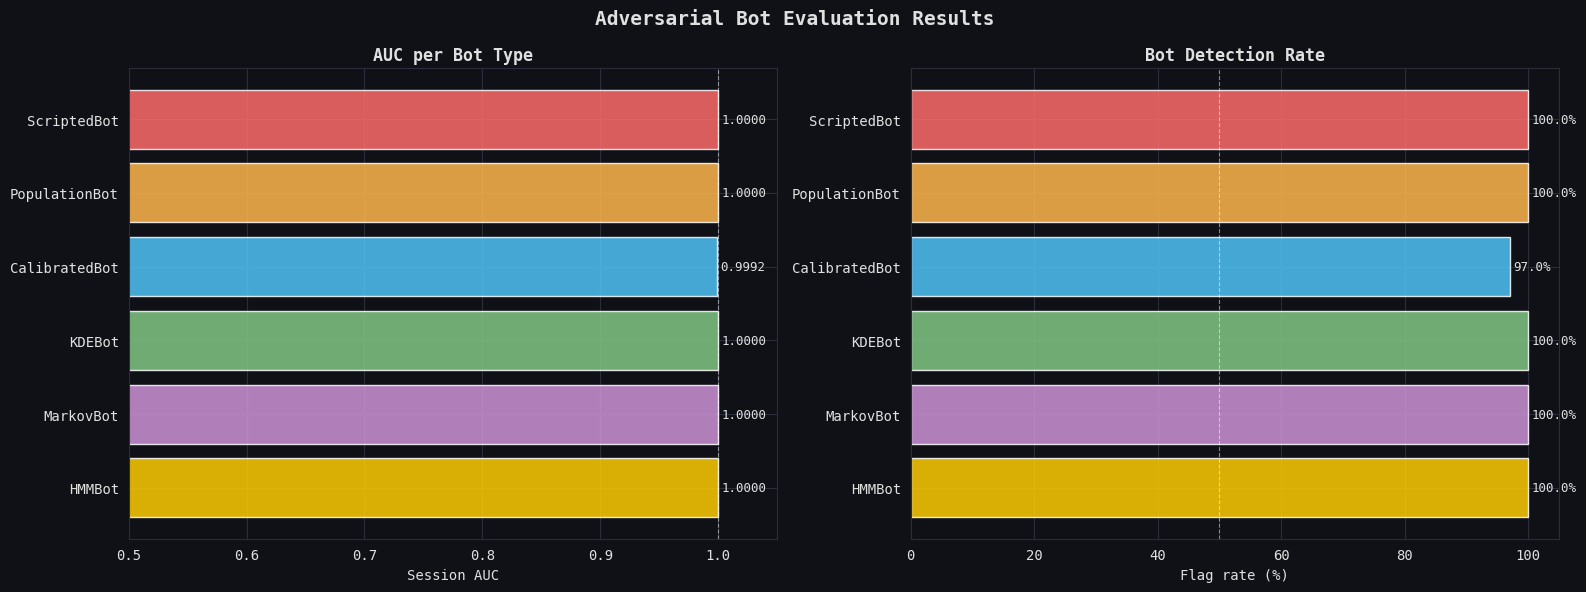

In [74]:
print('Adversarial evaluation — scoring all bots against the calibrated pipeline...')

adv_results = []
n_test_bots = 200

for bot_name, factory in BOT_FACTORIES.items():
    scores_bot = []
    for _ in range(n_test_bots):
        scores_bot.append(bot_detector.session_score(factory()))
    scores_bot = np.array(scores_bot)

    # Combine with human scores for AUC
    combined_s = np.concatenate([h_scores, scores_bot])
    combined_l = np.array([0]*len(h_scores) + [1]*len(scores_bot))
    if len(np.unique(combined_l)) > 1:
        auc = roc_auc_score(combined_l, combined_s)
    else:
        auc = float('nan')

    flag_rate = np.mean(scores_bot >= eer_thresh)
    adv_results.append({
        'Bot':         bot_name,
        'AUC':         auc,
        'Flag rate':   flag_rate,
        'Mean score':  np.mean(scores_bot),
        'Min score':   np.min(scores_bot),
    })
    print(f'  {bot_name:<18} AUC={auc:.4f}  flag_rate={flag_rate*100:.1f}%  mean_score={np.mean(scores_bot):.4f}')

adv_df = pd.DataFrame(adv_results).set_index('Bot')

# VIZ: AUC per bot type
fig, (ax1, ax2) = plt.subplots(1,2, figsize=(16,6))
bot_names = adv_df.index.tolist()
bot_colors = ['#FF6B6B','#FFB74D','#4FC3F7','#81C784','#CE93D8','#FFCC02'][:len(bot_names)]

bars1 = ax1.barh(bot_names, adv_df['AUC'], color=bot_colors, alpha=0.85)
ax1.axvline(1.0, color='white', lw=0.8, ls='--', alpha=0.5)
ax1.set_xlim(0.5, 1.05)
for bar, v in zip(bars1, adv_df['AUC']):
    ax1.text(v+0.003, bar.get_y()+bar.get_height()/2, f'{v:.4f}', va='center', fontsize=9)
ax1.set_xlabel('Session AUC'); ax1.set_title('AUC per Bot Type', fontweight='bold')
ax1.invert_yaxis()

bars2 = ax2.barh(bot_names, adv_df['Flag rate']*100, color=bot_colors, alpha=0.85)
ax2.axvline(50, color='white', lw=0.8, ls='--', alpha=0.5)
for bar, v in zip(bars2, adv_df['Flag rate']*100):
    ax2.text(v+0.5, bar.get_y()+bar.get_height()/2, f'{v:.1f}%', va='center', fontsize=9)
ax2.set_xlabel('Flag rate (%)'); ax2.set_title('Bot Detection Rate', fontweight='bold')
ax2.invert_yaxis()

plt.suptitle('Adversarial Bot Evaluation Results', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('viz_adversarial.png', dpi=150, bbox_inches='tight')
plt.show()

In [75]:
import time as _time
print('='*80)
print('COMPLETE RESULTS SUMMARY')
print('='*80)
print()
print('--- All Models (sorted by F1) ---')
print(res_df[['Accuracy','F1','AUC']].sort_values('F1', ascending=False).to_string())
print()
print('--- Compute Efficiency (training) ---')
print(comp_df.to_string())
print()
print('--- Session-Level Pipeline ---')
print(f'  Session AUC (in-distribution): {session_auc:.4f}')
print(f'  EER: {eer*100:.2f}%  at threshold {eer_thresh:.4f}')
print()
print('--- Adversarial Bot Detection ---')
print(adv_df[['AUC','Flag rate','Mean score']].to_string())
print()
# ── Inference latency per window (1000 reps on a single test sample) ─────
print('--- Inference latency (1 window = 200 keystrokes) ---')
N_REPS   = 1000
x_single = Xte_s[:1]           # 1 tabular feature vector
xs_single = Xs_te_s[:1]        # 1 sequence (500, 2)
infer_ms  = {}
for name, model in MODELS.items():
    if name == 'LSTM':
        t0 = _time.perf_counter()
        for _ in range(N_REPS): model.predict(xs_single, verbose=0)
        infer_ms[name] = (_time.perf_counter() - t0) / N_REPS * 1000
    elif name == 'MLP':
        t0 = _time.perf_counter()
        for _ in range(N_REPS): model.predict(x_single, verbose=0)
        infer_ms[name] = (_time.perf_counter() - t0) / N_REPS * 1000
    else:
        t0 = _time.perf_counter()
        for _ in range(N_REPS): model.predict_proba(x_single)
        infer_ms[name] = (_time.perf_counter() - t0) / N_REPS * 1000
print(f'  {"Model":<22} {"Infer ms/window":>16}  {"AUC":>8}  {"RAM (train MB)":>14}')
print('  ' + '-'*65)
for name in sorted(infer_ms, key=lambda n: infer_ms[n]):
    auc  = res_df.loc[name, 'AUC']
    ram  = comp_df.loc[name, 'Mem_MB']
    ms   = infer_ms[name]
    print(f'  {name:<22} {ms:>14.3f}ms  {auc:>8.4f}  {ram:>12.0f} MB')
print()
print('='*80)
# ── Best NN vs Best ML for DEPLOYMENT ────────────────────────────────────
nn_models = ['MLP', 'LSTM']
ml_models = ['Logistic Regression', 'Random Forest', 'XGBoost', 'Gradient Boosting', 'SVM', 'KNN']
nn_df = res_df.loc[[m for m in nn_models if m in res_df.index]]
ml_df = res_df.loc[[m for m in ml_models if m in res_df.index]]
# For deployment: pick highest AUC among models with inference <5ms
fast_ml = {n: infer_ms[n] for n in ml_models if n in infer_ms}
fast_nn = {n: infer_ms[n] for n in nn_models if n in infer_ms}
best_ml = max(fast_ml, key=lambda n: res_df.loc[n,'AUC'])
best_nn = max(fast_nn, key=lambda n: res_df.loc[n,'AUC'])
print('BEST FOR CONTINUOUS DEPLOYMENT -- NEURAL NETWORK')
print(f'  Model           : {best_nn}')
print(f'  AUC             : {nn_df.loc[best_nn,"AUC"]:.4f}')
print(f'  F1              : {nn_df.loc[best_nn,"F1"]:.4f}')
print(f'  Inference       : {infer_ms[best_nn]:.3f} ms per window')
print(f'  Memory (loaded) : ~{comp_df.loc[best_nn,"Mem_MB"]:.0f} MB')
print()
print('BEST FOR CONTINUOUS DEPLOYMENT -- CLASSICAL ML')
print(f'  Model           : {best_ml}')
print(f'  AUC             : {ml_df.loc[best_ml,"AUC"]:.4f}')
print(f'  F1              : {ml_df.loc[best_ml,"F1"]:.4f}')
print(f'  Inference       : {infer_ms[best_ml]:.3f} ms per window')
print(f'  Memory (loaded) : ~{comp_df.loc[best_ml,"Mem_MB"]:.0f} MB')
print()
auc_gap  = res_df.loc[best_nn,'AUC'] - res_df.loc[best_ml,'AUC']
spd_gap  = infer_ms[best_nn] / infer_ms[best_ml]
print('--- Deployment trade-off ---')
print(f'  {best_nn} vs {best_ml}')
print(f'  AUC gain   : {auc_gap:+.4f}')
print(f'  Speed cost : {spd_gap:.1f}x slower per window')
if abs(auc_gap) < 0.01:
    print(f'  Verdict    : AUC gap < 0.01  =>  {best_ml} is the practical choice for background monitoring')
else:
    print(f'  Verdict    : AUC gap = {auc_gap:.4f}  =>  {best_nn} justifies the overhead')


COMPLETE RESULTS SUMMARY

--- All Models (sorted by F1) ---
                     Accuracy        F1       AUC
Model                                            
Logistic Regression    0.8460  0.841368  0.915425
MLP                    0.8472  0.838819  0.925165
SVM                    0.8484  0.838792  0.921618
Random Forest          0.8144  0.826477  0.914795
XGBoost                0.8176  0.823393  0.914890
Gradient Boosting      0.8036  0.820999  0.918847
KNN                    0.7936  0.812227  0.890921
LSTM                   0.7460  0.691748  0.825272

--- Compute Efficiency (training) ---
                         Time_s      Mem_MB
Model                                      
Logistic Regression    0.017412    5.421875
Random Forest          0.315564   17.175781
XGBoost                0.234415    7.015625
Gradient Boosting      1.819389    1.371094
SVM                    1.299716   30.746094
KNN                    0.003540    0.175781
MLP                    4.593067   56.578125
LSTM 